## Setup

### Imports

In [1]:
%load_ext autoreload
%autoreload 3 --print
# import os; os.environ['JAX_PLATFORM_NAME'] = 'cpu'
# import os; os.environ['XLA_PYTHON_CLIE|NT_MEM_FRACTION'] = '.95'

In [2]:
from shape_norm.project.paths import Project, create_model
from shape_norm.io import loaders
from shape_norm.models import joint
from shape_norm import config
from shape_norm.models import instantiation, setup, pose, morph, util as model_util
from shape_norm import fitting
from shape_norm.fitting import em
from shape_norm.io import alignment, features
from shape_norm.io.armature import Armature
from shape_norm.fitting import methods
from shape_norm.fitting import scans
from shape_norm.pca import fit_with_center, CenteredPCA, PCAData
from shape_norm.io.dataset import PytreeDataset
from shape_norm.io.dataset_refactor import Dataset, SessionMetadata, StackedArrayMetadata
from shape_norm.models.morph.lowrank_affine import LRAParams, model as lra_model
from shape_norm import pca
from blscale_loader import loader, linear_skeletal as blscale_ls
import os, sys, shutil
import numpy as np
from pprint import pprint
from matplotlib import colors as mpl_col
import jax.numpy as jnp
import itertools as iit
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import GaussianMixture
import matplotlib as mpl
import seaborn as sns
from shape_norm import viz
from shape_norm.viz import styles
from scipy.spatial.distance import jensenshannon
from tensorflow_probability.substrates import jax as tfp
from ruamel.yaml import YAML
from bidict import bidict
import matplotlib.pyplot as plt
from collections import defaultdict
import os, re
import tqdm
from cmap import Colormap
import joblib as jl

from pathlib import Path
import logging
logging.getLogger().setLevel(logging.INFO)

### Supporting functions

#### KPSN utility functions


In [3]:
from supporting_funcs.shapenorm_helpers import (
    single_session_dataset,
    lra_anchor_poses,
    anchor_keypoints,
    unalign_scales,
    anchor_magnitudes,
    merge_morphs,
)

# def single_session_dataset(data, body, session, meta: SessionMetadata):
#     session_id = meta.session_id(session)
#     body_id = meta.body_id(body)
#     return Dataset(
#         data=data,
#         session_meta=meta.update(
#             session_bodies={**meta._session_bodies, session_id: body_id}
#         ),
#         stack_meta=StackedArrayMetadata(
#             slices={session_id: (0, len(data))}, length=len(data)
#         ),
#     )


# # model manipulation
# def lra_anchor_poses(params: LRAParams, magnitudes=90):
#     """
#     Parameters:
#     params (LRAParams):
#         Parameters used for calculating anchor poses.
#     magnitudes (float, numpy.ndarray):
#         The magnitude value used in calculating anchor poses. If a float, the
#         same magnitude is used for all anchors. If an array, the magnitude
#         for each dimension is specified separately. Not applied to the centroid
#         anchor.

#     Returns, (array, shape (n_bodies, n_dims, n_modes + 1)):
#     numpy.ndarray:
#         The anchor poses in the canonical pose space.
#     """

#     L = params.n_dims

#     if isinstance(magnitudes, (int, float)):
#         magnitudes = magnitudes * np.ones(L)

#     # (n_bodies, n_dims, 1)
#     anchors = (params.offset + params.offset_updates).reshape(
#         params.n_bodies, -1, 1
#     )
#     # (n_bodies, n_dims, n_modes + 1)
#     anchors = np.concatenate(
#         [
#             anchors,
#             anchors
#             + magnitudes[None, None] * (params.modes + params.mode_updates),
#         ],
#         axis=-1,
#     )

#     return anchors


# def anchor_keypoints(
#     params: LRAParams,
#     align_meta: dict,
#     magnitudes=90,
#     _inflate=None,
#     config=None,
#     session_meta: SessionMetadata = None,
# ):
#     """
#     Calculate and return the anchor poses from a model in the original keypoint
#     space.

#     This function computes anchor poses based on the provided parameters and
#     alignment metadata, inflates the poses based on a given configuration (if
#     any), and then applies inverse alignment scaling to return the poses in
#     their original keypoint space.

#     Parameters
#     ----------
#     params, dict:
#         Parameters used for calculating anchor poses.
#     session_meta, SessionMetadata, optional:
#         Session metadata object (accessible via dataset.session_meta) for
#         mapping body indices to session indices for rescaling. Required if
#         align_meta is provided. If provided, first index of output is over
#         session ids, not body ids.
#     align_meta, dict:
#         Metadata for alignment, optionally including scaling factors under the
#         key `scale`.
#     magnitudes, int, optional:
#         The magnitude value used in calculating anchor poses. Defaults to 90.
#     _inflate, function, optional:
#         A custom function to inflate anchor poses. If None, a default inflation
#         based on the 'features' configuration is used.
#     config, dict, optional:
#         Configuration dictionary that, if provided, is used to inflate the
#         anchor poses using the '_inflate' function. It should contain a
#         'features' key if'_inflate' is not provided.

#     Returns
#     -------
#     numpy.ndarray, shape (n_bodies or n_sessions, n_anchor, n_keypt, n_spatial):
#         The anchor poses in the original keypoint space after applying inverse
#         alignment scaling. If session_meta is provided, the first index is over
#         sessions instead of bodies.


#     """
#     if _inflate is None:
#         _inflate = lambda x: features.inflate(x, config["features"])
#     anchor_poses = lra_anchor_poses(
#         params, magnitudes
#     )  # (n_bodies, n_feat, n_anch)
#     inflated = _inflate(anchor_poses.transpose(0, 2, 1))
#     if session_meta is not None:
#         inflated = jnp.array(
#             [
#                 inflated[session_meta.session_body_id(i)]
#                 for i in range(len(session_meta._session_ids))
#             ]
#         )
#         if "scale" in align_meta:
#             inflated = alignment._inverse_align_scales(
#                 inflated, align_meta["scale"][:, None], stacked=True
#             )
#     return inflated


# def unalign_scales(align_meta, dataset, split_meta=None, base_dataset=None):
#     """
#     Invert scaling alignment, potentially on a split dataset

#     Parameters
#     ----------
#     align_meta : dict
#         The alignment metadata, containing an array under key 'scale' whose
#         $i$th element is the scale factor to be applied to sesssion with id $i$.
#     dataset : Dataset
#         The dataset to invert the scaling on.
#     split_meta : tuple, optional
#         Tuple whos second element (index 1) maps original session names (in
#         `dataset`) to the names of sessions in `dataset`.
#     base_dataset : Dataset, optional
#         Dataset with session ids that match the indices of
#         `align_meta['scale']`. Can be provided if `dataset` is a split dataset
#         where alignment was already performed before splitting.
#     """
#     if base_dataset is not None:
#         scan_align_meta = {"scale": np.array([-1.0 for _ in dataset.sessions])}
#         for src_sess, splits in split_meta[1].items():
#             for s in splits:
#                 scan_align_meta["scale"][dataset.session_id(s)] = align_meta[
#                     "scale"
#                 ][base_dataset.session_id(src_sess)]
#         align_meta = scan_align_meta
#     return (
#         alignment._inverse_align_scales(dataset, align_meta["scale"]),
#         align_meta,
#     )


# def anchor_magnitudes(
#     dataset: Dataset, params: LRAParams, q=0.9, canonicalized=False
# ):
#     """
#     Sample the `q`th percentile in absolute value from distributions of anchor
#     pose coordinates.

#     Parameters
#     ----------
#     dataset : Dataset or jnp.array
#         Feature data, in canonical pose space if `canonicalized` is True. If an
#         array, it is assumed to be in canonical pose space.
#     model : MorphModel
#     params : LRAParams
#         Parameters of the model.
#     q : float, default 0.9
#         The quantile to sample from.
#     canonicalized : bool, default False
#         Whether the dataset is already in canonical pose space (magnitudes are
#         not session- or body-dependent)

#     Returns
#     -------
#     magnitudes : array, shape (n_modes,)
#         The selected magnitude in each morph mode.
#     """
#     if canonicalized:
#         canonical = dataset.data
#     elif isinstance(dataset, jnp.ndarray):
#         canonical = dataset
#     else:
#         canonical = model_util.apply_bodies(
#             lra_model,
#             params,
#             dataset,
#             {
#                 s: dataset.session_body_name(dataset.ref_session)
#                 for s in dataset.sessions
#             },
#         ).data

#     coords = canonical @ params.modes  # (n_pts, n_modes)
#     qix = jnp.argsort(coords, axis=0)[int(coords.shape[0] * q)]  # argquantile
#     selected_coord = coords[qix, jnp.arange(coords.shape[1])]
#     return selected_coord


# def merge_morphs(
#     params: LRAParams,
#     merged_session_meta: SessionMetadata,
#     split_session_meta: SessionMetadata,
#     split_meta: dict,
# ):
#     """
#     Merge morph parameters from a split dataset into a single dataset.

#     Parameters
#     ----------
#     params : LRAParams
#         The morph parameters.
#     merged_session_meta, split_session_metadata : SessionMetadata
#         Session metadata object (accessible via dataset.session_meta) for
#         identifying body ids.
#     split_meta : dict
#         Metadata for the split dataset, containing a mapping original body names
#         to sessions in the split dataset.

#     Returns
#     -------
#     numpy.ndarray, shape (n_sessions, n_modes, n_dims)
#         The merged morph parameters.
#     """
#     body_inv = {
#         b: [split_session_meta.session_body_name(s) for s in split_meta[b]]
#         for b in split_meta
#     }
#     new_nbod = len(merged_session_meta._body_ids)
#     new_ref = None
#     mode_upds = np.zeros((new_nbod, params.n_feats, params.n_dims))
#     ofs_upds = np.zeros((new_nbod, params.n_feats))
#     for i in range(new_nbod):
#         merged_bod = merged_session_meta.body_name(i)
#         i_mode_upds = []
#         i_ofs_upds = []
#         for split_bod in body_inv[merged_bod]:
#             j = split_session_meta.body_id(split_bod)
#             i_mode_upds.append(params.mode_updates[j])
#             i_ofs_upds.append(params.offset_updates[j])
#             if j == params.ref_body:
#                 new_ref = i
#         mode_upds[i] = np.mean(i_mode_upds, axis=0)
#         ofs_upds[i] = np.mean(i_ofs_upds, axis=0)

#     return LRAParams(
#         {
#             **params._tree,
#             **dict(
#                 n_bodies=new_nbod,
#                 ref_body=new_ref,
#                 _mode_updates=jnp.array(mode_upds),
#                 _offset_updates=jnp.array(ofs_upds),
#             ),
#         }
#     )

#### Dataset utility functions

In [4]:
from supporting_funcs.keypoint_data import (
    mouse_data_armature_meta as raw_data_armature_meta,
    blscale_dataset,
)

# def raw_data_armature_meta():
#     """Organize metadata on keypoints and skeleton of mouse data."""
#     names = [
#         'shldr', 'back', 'hips', 't_base','t_tip', 'head',
#         'l_ear', 'r_ear', 'nose', 'lr_knee', 'lr_foot',
#         'rr_knee', 'rr_foot', 'lf_foot', 'rf_foot']
#     parents = dict(zip(names, [
#         'back', 'hips', None, 'hips', 't_base', 'shldr',
#         'head', 'head', 'head', 'hips', 'lr_knee',
#         'hips', 'rr_knee', 'shldr', 'shldr']))
#     keypt_ix = lambda name: names.index(name)
#     bones = np.array([(keypt_ix(c), keypt_ix(p)) for c, p in parents.items() if p])
#     root = keypt_ix("shldr")
#     bones = blscale_ls.reroot(bones, root)
#     bones = bones[np.argsort(bones[:, 0])]
#     return names, parents, bones, root

# _with_match = lambda test, pattern, f: f(m) if (m := re.search(pattern, test)) else None
# _name_func = lambda path, *a: _with_match(
#     path, r"(?:/.*)+/\d{2}_\d{2}_\d{2}_(\d+wk_m\d+)\.npy",
#     lambda m: f"{m.group(1)}")

# def blscale_dataset(source_dict, scale_dict, data_dir, ref_session = None):
#     """
#     Create a dataset using `blscale_loader`

#     Parameters
#     ----------
#     source_dict : str or Path
#         Path to the source dictionary
#     scale_dict : str or Path
#         Path to the scale dictionary

#     Returns
#     -------
#     project_config_kws : dict
#         Keyword args for `loaders.arrays.setup_project_config`
#     coords : dict
#         Dictionary mapping session names to (unaligned) keypoint data
#     scales : dict
#         Dictionary mapping session names to scale bone-wise scale factors and
#         uniform scale factors.
#     """
#     session_names = loader.find_sessions(
#         sources = source_dict,
#         scales = scale_dict,
#         ext = '.npy',
#         name_func = _name_func,
#     )
#     session_bodies = {s: f"body-{s}" for s in session_names}

#     # skeleton without dropped keypoints
#     names, parents, bones, root = raw_data_armature_meta()

#     coords, _, _ = loader.external_scale(
#         data_dir,
#         sources=source_dict,
#         scales=scale_dict,
#         bones=bones,
#         root_keypoint_ix=root,
#         ext=".npy",
#         name_func=_name_func,
#     )
#     _, scales = loader._align_scales_sources(
#         source_dict, scale_dict, ext=".npy", name_func=_name_func
#     )

#     ref_session = list(coords.keys())[0]

#     project_config_kws = {
#         "session_names": list(coords.keys()),
#         "bodies": session_bodies,
#         "ref_session": ref_session,
#         "keypoint_names": names,
#         "keypoint_parents": parents,
#     }

#     return project_config_kws, coords, scales

#### Plotting utility functions

In [5]:
from supporting_funcs.plotting import getc, plot_mouse_3d

# def getc(spec):
#     try:
#         from cmap import Colormap, Color
#         try:
#             return Color(spec)
#         except ValueError as e:
#             stop = spec.split(':')[-1]
#             if stop.startswith('.'):
#                 stop = float(stop)
#             else:
#                 stop = int(stop)
#             cm = Colormap(':'.join(spec.split(':')[:-1]))
#             return cm(stop)
#     except ImportError:
#         return spec

# def plot_mouse_3d(
#     frame,
#     ax,
#     armature,
#     elev,
#     rot,
#     colors=None,
#     bone_n=40,
#     point_size=10,
#     line_size=2,
#     line_colors=None,
#     point_kws={},
#     line_kws={},
#     boundary=True,
#     set_aspect=True,
#     label = None
# ):
#     """all keys in point kws should be present in line kws"""

#     if colors is None:
#         import seaborn as sns

#         colors = mpl_col.to_rgba(sns.color_palette("Blues", 10 + frame.shape[0])[10:])
#     if line_colors is None:
#         line_colors = colors
#     colors = np.array([mpl_col.to_rgba(x) for x in colors])
#     line_colors = np.array([mpl_col.to_rgba(x) for x in line_colors])
#     point_kws = {
#         **dict(
#             linewidths=np.array([0] * armature.n_kpts),
#         ),
#         **point_kws,
#     }
#     line_kws = {
#         **dict(
#             linewidths=np.array([0] * armature.n_kpts),
#         ),
#         **line_kws,
#     }

#     # --- points

#     x, y, z, c, s = [], [], [], [], []
#     x.append(frame[:, 0])
#     y.append(frame[:, 1])
#     z.append(frame[:, 2])
#     c.append(colors)
#     s.append([point_size] * armature.n_kpts)
#     kws = {k: [] for k in point_kws}
#     concat_keys = []
#     for k, v in point_kws.items():
#         if np.array(v).shape[:1] == (armature.n_kpts,):
#             concat_keys.append(k)
#             kws[k].append(v)
#         else:
#             kws[k] = v

#     x = np.concatenate(x)
#     y = np.concatenate(y)
#     z = np.concatenate(z)
#     c = np.concatenate(c)
#     s = np.concatenate(s)
#     for k, v in kws.items():
#         if k in concat_keys:
#             kws[k] = np.concatenate(kws[k])
#     point_artist = ax.scatter(x, y, z, c=c, s=s, depthshade=False, **kws)

#     # --- "lines"

#     x, y, z, c, s = [], [], [], [], []
#     kws = {k: [] for k in line_kws}
#     concat_keys = []
#     for i, (ch, pa) in enumerate(armature.bones):
#         x.append(np.linspace(frame[ch, 0], frame[pa, 0], bone_n)[1:-1])
#         y.append(np.linspace(frame[ch, 1], frame[pa, 1], bone_n)[1:-1])
#         z.append(np.linspace(frame[ch, 2], frame[pa, 2], bone_n)[1:-1])
#         c.append(np.full([bone_n - 2, 4], line_colors[ch]))
#         s.append(np.full([bone_n - 2], line_size))
#         for k, v in line_kws.items():
#             if np.array(v).shape[:1] == (armature.n_kpts,):
#                 concat_keys.append(k)
#                 kws[k].append(np.full((bone_n - 2,) + np.array(v).shape[1:], v[ch]))
#             else:
#                 kws[k] = v
#     x = np.concatenate(x)
#     y = np.concatenate(y)
#     z = np.concatenate(z)
#     c = np.concatenate(c)
#     s = np.concatenate(s)
#     for k, v in kws.items():
#         if k in concat_keys:
#             kws[k] = np.concatenate(kws[k])

#     line_artist = ax.scatter(x, y, z, c=c, s=s, depthshade=False, **kws)

#     ax.view_init(elev, rot)

#     ax.grid(False)
#     ax.xaxis.pane.fill = False
#     ax.yaxis.pane.fill = False
#     ax.zaxis.pane.fill = False
#     ax.xaxis.set_ticks([])
#     ax.yaxis.set_ticks([])
#     ax.zaxis.set_ticks([])
#     if not boundary:
#         ax.xaxis.pane.set_linewidth(0)
#         ax.yaxis.pane.set_linewidth(0)
#         ax.zaxis.pane.set_linewidth(0)
#         ax.xaxis.line.set_linewidth(0)
#         ax.yaxis.line.set_linewidth(0)
#         ax.zaxis.line.set_linewidth(0)

    
#     # use a.set_box_aspect to make the aspect equal to the ratio of the limits
#     if set_aspect:
#         xrng = np.ptp(ax.get_xlim())
#         yrng = np.ptp(ax.get_ylim())
#         zrng = np.ptp(ax.get_zlim())
#         ax.set_box_aspect([xrng, yrng, zrng])

#     return point_artist, line_artist

#### Linear classifier utility functions

In [6]:
from supporting_funcs.classifiers import (
    indiv_holdout,
    frame_holdout,
    pairwise_group_acc,
    allway_group_acc,
    pairwise_framewise_acc,
    named_group_pairwise_framewise_acc,
    calculate_feat_scaled_kp_normed,
    calc_all_scores,
    calc_indiv_filtered_scores,
    classif_strip,
    classif_strip_points,
)

# def indiv_holdout(feats, groups, seed, shuffle):
#     rng = np.random.default_rng(seed)
#     feat_val = []
#     feat_trn = []
#     tgt_val = []
#     tgt_trn = []
#     tgt_keys = dict(zip(groups.keys(), range(len(groups))))
#     for grp_key, grp in groups.items():
#         holdout = rng.integers(len(grp))
#         feat_val.append(feats[grp[holdout]])
#         feat_trn.extend([feats[s] for i, s in enumerate(grp) if i != holdout])
#         lens = [len(feats[s]) for s in grp]
#         tgt_val.append(np.full(lens[holdout], tgt_keys[grp_key]))
#         tgt_trn.extend([np.full(l, tgt_keys[grp_key]) for i, l in enumerate(lens) if i != holdout])
#     feat_val = np.concatenate(feat_val, axis = 0)
#     feat_trn = np.concatenate(feat_trn, axis = 0)
#     tgt_val = np.concatenate(tgt_val, axis = 0)
#     tgt_trn = np.concatenate(tgt_trn, axis = 0)
#     if shuffle:
#         tgt_trn = rng.permutation(tgt_trn)
#     return feat_trn, feat_val, tgt_trn, tgt_val

# def frame_holdout(feats, groups, seed, shuffle, train_pct = 0.5):
#     if isinstance(seed, int):
#         rng = np.random.default_rng(seed)
#     else:
#         rng = seed
#     feat_val = []
#     feat_trn = []
#     tgt_val = []
#     tgt_trn = []
#     tgt_keys = dict(zip(groups.keys(), range(len(groups))))
#     for grp_key, grp in groups.items():
#         for s in grp:
#             x = feats[s]
#             trn, val = np.split(rng.permutation(len(x)), [int(train_pct * len(x))])
#             feat_trn.append(x[trn])
#             feat_val.append(x[val])
#             tgt_trn.append(np.full(len(trn), tgt_keys[grp_key]))
#             tgt_val.append(np.full(len(val), tgt_keys[grp_key]))
#     feat_val = np.concatenate(feat_val, axis = 0)
#     feat_trn = np.concatenate(feat_trn, axis = 0)
#     tgt_val = np.concatenate(tgt_val, axis = 0)
#     tgt_trn = np.concatenate(tgt_trn, axis = 0)
#     if shuffle:
#         tgt_trn = rng.permutation(tgt_trn)
#     return feat_trn, feat_val, tgt_trn, tgt_val

# def pairwise_group_acc(feats, groups, ref, nonref, n_iter = 40):
#     scores = {a: [] for a in nonref}
#     scores_null = {a: [] for a in nonref}
#     for is_null, scores_dict in enumerate([scores, scores_null]):
#         for nonref_age in tqdm.tqdm(nonref):
#             for seed in range(n_iter):
#                 xt, xv, yt, yv = indiv_holdout(
#                     feats,
#                     {ref: groups[ref], nonref_age: groups[nonref_age]},
#                     seed,
#                     shuffle = is_null
#                 )
#                 model = LogisticRegression(max_iter=1000, class_weight="balanced")
#                 scores_dict[nonref_age].append(model.fit(xt, yt).score(xv, yv))
#     return scores, scores_null

# def allway_group_acc(feats, groups, n_iter = 40, subsample = 1, clf_kws = {}, prescale = False):
#     scores_list = [[], []]
#     for is_null in range(2):
#         for seed in tqdm.trange(n_iter):
#             xt, xv, yt, yv = indiv_holdout(
#                 {k: v[::subsample] for k, v in feats.items()},
#                 groups,
#                 seed,
#                 shuffle = is_null
#             )
#             if prescale:
#                 m, sd = xt.mean(axis = 0), xt.std(axis = 0)
#                 xt = (xt - m) / sd
#                 xv = (xv - m) / sd
#             model = LogisticRegression(**{**dict(max_iter=1000, class_weight="balanced"), **clf_kws})
#             scores_list[is_null].append(model.fit(xt, yt).score(xv, yv))
#     return scores_list

# def pairwise_framewise_acc(feats, groups, n_iter = 1, across_mode = 'none', rng = None):
#     """
#     Returns
#     -------
#     across_group : list
#         Frames taken from sessions in different groups forming positive and
#         negative example sets.
#     across_group_null : list
#         As in `across_group` but with shuffled labels.
#     within_group : list
#         Frames from different sessions within the same group forming positive
#         and negative example sets.
#     within_session : list
#         Sets of frames taken from within the same session forming positive and
#         negative example sets.
#     """
#     scores_list = [[], [], [], []]
#     combos = list(iit.combinations(groups.keys(), 2)) + [(k, k) for k in groups.keys()]
#     if rng is None:
#         rng = np.random.default_rng()
#     for g1, g2 in tqdm.tqdm(combos):
#         within_group = g1 == g2
#         if across_mode == 'across-only' and within_group:
#             continue
#         if across_mode == 'within-only' and not within_group:
#             continue
#         for is_null in range(2 if not within_group else 1):
#             for i, (s1, s2) in enumerate(iit.product(groups[g1], groups[g2])):
#                 within_animal = s1 == s2
#                 for j in range(n_iter):
#                     xt, xv, yt, yv = frame_holdout(
#                         feats,
#                         {'s1': [s1], 's2': [s2]},
#                         rng,
#                         shuffle = is_null
#                     )
#                     # print(np.unique(yt, return_counts=True), np.unique(yv, return_counts=True))
#                     model = LogisticRegression(max_iter=1000, class_weight="balanced")
#                     score_ix = 3 if within_animal else (2 if within_group else is_null)
#                     scores_list[score_ix].append(model.fit(xt, yt).score(xv, yv))
#     return scores_list

# def named_group_pairwise_framewise_acc(feats, groups, n_iter = 1, across_mode = 'none', rng = None):
#     """
#     Returns
#     -------
#     across_group : dict
#         Frames taken from sessions in different groups forming positive and
#         negative example sets.
#     across_group_null : dict
#         As in `across_group` but with shuffled labels.
#     within_group : dict
#         Frames from different sessions within the same group forming positive
#         and negative example sets.
#     within_session : dict
#         Sets of frames taken from within the same session forming positive and
#         negative example sets.
#     """
#     scores_list = [defaultdict(list) for _ in range(4)]
#     combos = list(iit.combinations(groups.keys(), 2)) + [(k, k) for k in groups.keys()]
#     if rng is None:
#         rng = np.random.default_rng()
#     for g1, g2 in tqdm.tqdm(combos):
#         within_group = g1 == g2
#         if across_mode == 'across-only' and within_group:
#             continue
#         if across_mode == 'within-only' and not within_group:
#             continue
#         for is_null in range(2 if not within_group else 1):
#             for i, (s1, s2) in enumerate(iit.product(groups[g1], groups[g2])):
#                 within_animal = s1 == s2
#                 for seed in range(n_iter):
#                     xt, xv, yt, yv = frame_holdout(
#                         feats,
#                         {'s1': [s1], 's2': [s2]},
#                         rng,
#                         shuffle = is_null
#                     )
#                     model = LogisticRegression(max_iter=1000, class_weight="balanced")
#                     score_ix = 3 if within_animal else (2 if within_group else is_null)
#                     scores_list[score_ix][frozenset({g1, g2})].append(model.fit(xt, yt).score(xv, yv))
#     return scores_list

# def calculate_feat_scaled_kp_normed(kpts_dict, arms, subsample = 1):
#     """Convert dictionary of keypoints to normalized feature vectors"""
#     sessions = list(kpts_dict.keys())
#     feat_scaled_kp = {
#         s: kpts_dict[s][::subsample].reshape(-1, arms.n_kpts * 3)
#         for s in sessions
#     }
#     norm_stats = [
#         np.mean(np.concatenate(list(feat_scaled_kp.values())), axis=0),
#         np.std(np.concatenate(list(feat_scaled_kp.values())), axis=0),
#     ]
#     keep_ixs = np.where(norm_stats[1] > 1e-3)[0]
#     norm_stats[1] = np.where(norm_stats[1] == 0, 1, norm_stats[1])
#     return {
#         s: ((feat_scaled_kp[s] - norm_stats[0]) / norm_stats[1])[:, keep_ixs]
#         for s in sessions
#     }

# def calc_all_scores(feats_dict, groups, ref_age, tgt_ages):
#     """Compute accuracy for all for cohort and individual comparisons"""
#     c_scores, c_scores_null = pairwise_group_acc(feats_dict, groups, ref_age, tgt_ages)
#     c_indiv_across, c_indiv_null, c_indiv_within, c_indiv_self = pairwise_framewise_acc(feats_dict, groups)
#     c_indiv = c_indiv_across, c_indiv_within, c_indiv_self, c_indiv_null
#     return c_scores, c_scores_null, c_indiv

# def calc_indiv_filtered_scores(feats_dict, groups, ref_age, tgt_ages, indiv_groups, n_iter = 1, seed = 9729):
#     """
#     `calc_all_scores`, with comparisons across group only performed within
#     sessions in the same `indiv_group`

#     This avoids comparing across both distortion and behavior variance
#     """
#     scores, scores_null = [defaultdict(list) for _ in range(2)]
#     rng = np.random.default_rng(seed)
#     for indiv, indiv_sessions in indiv_groups.items():
#         indiv_groups = {g: [s for s in v if s in indiv_sessions] for g, v in groups.items()}
#         indiv_groups = {g: v for g, v in indiv_groups.items() if len(v)}
#         indiv_scores, indiv_null, _, _ = named_group_pairwise_framewise_acc(feats_dict, indiv_groups, n_iter=n_iter, across_mode='across-only', rng=rng)
#         for k in indiv_scores:
#             if ref_age in k:
#                 k_tgt = [g for g in k if g != ref_age][0]
#                 scores[k_tgt].extend(indiv_scores[k])
#                 scores_null[k_tgt].extend(indiv_null[k])
#     allway_scores = pairwise_framewise_acc(feats_dict, groups, n_iter=n_iter, across_mode='none', rng=rng)
#     return scores, scores_null, allway_scores


# classif_strip = lambda ax, keys, data, colors, offset, point_ms=0.5, **kws: viz.util.grouped_stripplot(
#     viz.util.expand_groups([np.array(data[a]) for a in keys], keys),
#     x=np.arange(len(keys)) + offset,
#     ax=ax,
#     colors=dict(zip(keys, colors)),
#     points_kw=dict(ms=point_ms),
#     errorbar_kw=dict(ms=2, elinewidth=0),
#     **{
#         **dict(
#             xticks="",
#             lighten_points=0.5,
#             offset=False,
#         ),
#         **kws,
#     },
# )

# classif_strip_points = lambda ax, keys, data, colors, offset, point_ms=0.7, **kws: viz.util.grouped_stripplot(
#     viz.util.expand_groups([np.array(data[a]) for a in keys], keys),
#     x=np.arange(len(keys)) + offset,
#     ax=ax,
#     colors=dict(zip(keys, colors)),
#     points_kw=dict(ms=point_ms),
#     errorbar_kw=dict(ms=0, elinewidth=0),
#     jitter=0.1,
#     **{
#         **dict(
#             xticks="",
#             lighten_points=False,
#             offset=False,
#         ),
#         **kws,
#     },
# )

#### Naive model functions

In [7]:
from supporting_funcs.shapenorm_helpers import (
    naive_model_params,
    naive_model_anchors,
)


# def naive_model_params(ref_pc, upds_best, ref_center, alt_center, ref_body_id):
#     return LRAParams(
#         dict(
#             n_bodies=len(alt_center) + 1,
#             n_feats=ref_pc.shape[0],
#             ref_body=ref_body_id,
#             n_dims=ref_pc.shape[1],
#             prior_mode="distance",
#             # --- hyperparams
#             upd_var_modes=1.0,
#             upd_var_ofs=1.0,
#             dist_var=1.0,
#             modes=jnp.array(ref_pc),
#             offset=jnp.array(ref_center),
#             # --- trainable params
#             _mode_updates=jnp.array(
#                 np.insert(upds_best, ref_body_id, 0, axis=0)
#             ),
#             _offset_updates=jnp.array(
#                 np.insert(alt_center - ref_center[None], ref_body_id, 0, axis=0)
#             ),
#         )
#     )


# def naive_model_anchors(
#     canonicalized_dict, session_params, config, magnitudes=None
# ):
#     """Compute anchor poses for a collection of naive models fit to session
#     half pairs.

#     Parameters
#     ----------
#     canonicalized_dict : dict
#         Dictionary of canonicalized keypoints, with keys <session>.<part>
#     session_params : dict
#         Dictionary of session morph parameters, with keys <session>
#     config : dict
#         Configuration used to inflate from features to keypoints

#     Returns
#     -------
#     anchors : dict[str, array (2,n_anchor, n_kpt, 3)]
#         Dictionary of anchor poses, with keys <session>, containing anchor poses
#         for each parameter set.
#     """
#     if magnitudes is None:
#         magnitudes = {
#             s: anchor_magnitudes(
#                 jnp.concatenate(
#                     [
#                         canonicalized_dict[f"{s}.0"],
#                         canonicalized_dict[f"{s}.1"],
#                     ]
#                 ),
#                 session_params[s],
#                 q=0.1,
#             )
#             for s in session_params
#         }
#     if not isinstance(magnitudes, dict):
#         magnitudes = {s: magnitudes for s in session_params}
#     return {
#         s: anchor_keypoints(
#             session_params[s],
#             {},
#             magnitudes=magnitudes[s],
#             config=config,
#         )
#         for s in session_params
#     }

### Panel setup

In [6]:
%matplotlib inline
%config InlineBackend.figure_format='retina'

# Output directory
plot_dir = '/Users/kaifox/projects/mph/data_explore/plots/notebook/panels/v6/f4.1_learns-morph'


# Index of locations for data files
data_paths_file = "/Users/kaifox/projects/mph/generative_api/test/notebooks/panels/data_paths.yml"
data_paths = YAML(typ='safe').load(open(data_paths_file, 'r'))


# Metadata for standardized plots
params_file = "/Users/kaifox/projects/mph/generative_api/test/notebooks/panels/plot_params.yml"

# Object for finalizing and saving plots
plot_meta = YAML(typ='safe').load(open(params_file, 'r'))
colors, plotter = styles.init_plt(plot_dir, style='default', fmt = 'pdf', **plot_meta['savefig'])
plt.rcParams.update(plot_meta['rc'])
plot_root = Path(plotter.plot_dir)

#### Load data

In [8]:
from supporting_funcs.data_loading import load_blscale_data

base = "3"
ref_session = "3wk_3bod_m0"


(source_dict, scale_dict, dataset_keyppoints, scales, project_config_kws) = (
    load_blscale_data(
        Path(data_paths["root"]) / Path(data_paths["mouse_blscale_scale_meta"]),
        Path(data_paths["root"]) / Path(data_paths["mouse_ont_keypoints"]),
        base,
        ref_session,
    )
)

# blscale_dir = Path('/Users/kaifox/projects/mph/data_explore/testsets/blscale-dicts')
# data_dir = Path("/Users/kaifox/projects/mph/data_explore/data")

# base = '3'
# source_dict = blscale_dir / "source-dicts" / "cohort-wise" / f"{base}wk-to-all.yaml"
# # scale_dict = blscale_dir / "scale-dicts" / "cohort-wise" / f"{base}wk-to-all_ntt-norm.yaml"
# scale_dict = blscale_dir / "scale-dicts" / f"all-to-named-age_unnormed.yaml"

# project_config_kws, dataset_keypoints, scales = blscale_dataset(source_dict, scale_dict, data_dir, ref_session='3wk_3bod_m0')

Loading keypoints: 100%|█████████████████| 4/4 [00:00<00:00, 349.84it/s]


Sessions: ['3wk_5bod_m1', '3wk_5bod_m0', '3wk_5bod_m2', '3wk_5bod_m3', '3wk_72bod_m1', '3wk_72bod_m0', '3wk_72bod_m2', '3wk_72bod_m3', '3wk_52bod_m1', '3wk_52bod_m0', '3wk_52bod_m2', '3wk_52bod_m3', '3wk_24bod_m1', '3wk_24bod_m0', '3wk_24bod_m2', '3wk_24bod_m3', '3wk_3bod_m1', '3wk_3bod_m0', '3wk_3bod_m2', '3wk_3bod_m3', '3wk_7bod_m1', '3wk_7bod_m0', '3wk_7bod_m2', '3wk_7bod_m3']


In [8]:
from supporting_funcs.data_loading import plotting_metadata

(
    sim_pal,
    age_pal,
    kp_order,
    kp_colors,
    kp_colormap,
    use_kpts,
    keypt_ix,
    _bones,
    arms,
    _,
    _,
    _,
    _,
    _,
    _,
    joint_names,
    joint_short_names,
    joint_by_short,
    joint_kp_ixs,
) = plotting_metadata(params_file)

In [9]:
# --- Select `shape_norm` project directory and metadata about the project


# project_dir = Path('../../projects/o2-blscale/fit05-1_all-animals_lowpc')
project_dir = Path(data_paths['root']) / Path(data_paths['mouse_blscale_shapenorm'])


# --- Load plotting style
# params_file = "/Users/kaifox/projects/mph/generative_api/test/notebooks/panels/plot_params.yml"
# plot_meta = YAML(typ='safe').load(open(params_file, 'r'))
# colors, plotter = styles.init_plt(plot_dir, style='default', fmt = 'pdf', **plot_meta['savefig'])
# plt.rcParams.update(plot_meta['rc'])
# plot_root = Path(plotter.plot_dir)

# plot_meta = YAML(typ='safe').load(open(params_file, 'r'))
# sim_pal = {k: getc(c) for k, c in plot_meta['colors']['sim_age'].items()}

# kp_order = []
# kp_colors = {}
# kp_colormap = Colormap(plot_meta['colors']['keypoint'][0])
# for kp_color in plot_meta['colors']['keypoint'][1:]:
#     for kp in kp_color[1:]:
#         kp_order.append(kp)
#         kp_colors[kp] = kp_colormap(kp_color[0])

# --- Organize metadata about reference and alternate groups
ref_age = '3'
tgt_age = '52'
scale_to = f"{ref_age}wk_{ref_age}bod_m0"
tgt_ages = ['5', '7', '24', '52', '72']
ref_color = sim_pal[ref_age]
tgt_color = sim_pal[tgt_age]
tgt_colors = [sim_pal[a] for a in tgt_ages]
animal_ids = list(range(4))



In [10]:
from supporting_funcs.data_loading import load_blscale_kpsn_model

scan_name = "morph-prior-scan"
model_name = "morph-prior-scan_2"

_kpsn_data = load_blscale_kpsn_model(
    project_dir,
    scan_name,
    model_name,
    params_file,
    Path(data_paths["root"])
    / Path(data_paths["mouse_blscale_scaled_keypoints"]),
)

project, ckpt, cfg, model, arms, params = _kpsn_data[0]
bone_names, short_names, bone_ix_order, bone_groups, bone_group_names = (
    _kpsn_data[1]
)
(
    dataset,
    scan_cfg,
    dataset_versions,
    split_meta,
    align_meta,
    scan_dataset,
    dataset_feats,
) = _kpsn_data[3]
(
    dataset_full,
    dataset_versions_full,
    scan_dataset_full,
    dataset_feats_full,
) = _kpsn_data[4]
blscale_metadata, blscale_uniform = _kpsn_data[5]
merged_params = _kpsn_data[6]

/n/groups/datta/kai/mph/testsets/blscale-arrays/3wk-to-all_ntt-norm


In [10]:
# Select and load model

# scan_name = 'morph-prior-scan'
# model_name = 'morph-prior-scan_2'

# ckpt = methods.load_fit(project.model(model_name))
# cfg = ckpt["config"]
# model = instantiation.get_model(cfg)
# arms = Armature.from_config(cfg["dataset"])
# params = ckpt["params"]

# # --- Organize bone names and order
# # bone_names = [f"{arms.keypoint_names[int(c)]}-{arms.keypoint_names[int(p)]}" for c, p in arms.bones]
# # short_names = bidict(plot_meta['armature']['short_names'])
# # bone_ix_order = [bone_names.index(short_names.inverse[b]) for b in plot_meta['armature']['order']]
# # bone_groups = plot_meta['armature']['groups']
# # bone_group_names = plot_meta['armature']['group_names']

# # if cfg['dataset']['type'] == "arrays":
# #     dataset = loaders.arrays.from_arrays(dataset_keypoints, cfg["dataset"])
# #     scan_dataset, split_meta, align_meta = scans.prepare_scan_dataset(dataset, project, scan_name, return_session_inv=True)

# if cfg['dataset']['type'] == 'raw_npy':

#     # Set location for keypoint data and calibration
#     root = Path(cfg['dataset']['root_path'])
#     print(root)
#     cfg['dataset']['root_path'] = Path('/Users/kaifox/projects/mph/data_explore/testsets/blscale-arrays/') / root.name
#     cfg['calibration_file'] = project_dir.resolve() / "project.calib.p"
    
#     # ignore any previously loaded blscale dataset
#     dataset_keypoints = None
#     project_config_kws = None
#     scales = None
    
#     # load dataset
#     dataset = loaders.load_dataset(cfg['dataset'])
#     scan_cfg = config.load_config(project.scan(scan_name) / 'scan.yml')
#     dataset_versions, split_meta, align_meta = scans.prepare_scan_dataset(dataset, cfg, return_session_inv=True, all_versions=True)
#     scan_dataset = dataset_versions["train"]
#     dataset_feats = dataset_versions["reduced"]
#     # load dataset without subsampling
#     dataset_full = loaders.load_dataset(cfg["dataset"], allow_subsample=False)
#     scan_dataset_full, _, _ = scans.prepare_scan_dataset(dataset_full, cfg)
#     dataset_versions_full, _, _ = scans.prepare_scan_dataset(dataset_full, cfg, return_session_inv=True, all_versions=True)
#     scan_dataset_full = dataset_versions_full["train"]
#     dataset_feats_full = dataset_versions_full["reduced"]

#     merged_params = merge_morphs(params.morph, dataset.session_meta, scan_dataset.session_meta, split_meta[0])
    
#     # integrate blscale "uniform" into alignment scales
#     blscale_metadata = YAML().load(cfg['dataset']['root_path'] / "metadata.yml")
#     blscale_uniform = {s: blscale_metadata['scale_dict'][s]['uniform'] for s in dataset.sessions}
#     align_meta['scale'] = [s / blscale_uniform[dataset.session_name(i)] for i, s in enumerate(align_meta['scale'])]

laodfing model config /Users/kaifox/projects/mph/generative_api/test/projects/o2-blscale/fit05-1_all-animals_lowpc/models/morph-prior-scan_2/model.yml
project path /Users/kaifox/projects/mph/generative_api/test/projects/o2-blscale/fit05-1_all-animals_lowpc/models/morph-prior-scan_2/../../project.yml
laodfing model config /Users/kaifox/projects/mph/generative_api/test/projects/o2-blscale/fit05-1_all-animals_lowpc/models/morph-prior-scan_2/model.yml
project path /Users/kaifox/projects/mph/generative_api/test/projects/o2-blscale/fit05-1_all-animals_lowpc/models/morph-prior-scan_2/../../project.yml
/n/groups/datta/kai/mph/testsets/blscale-arrays/3wk-to-all_ntt-norm


#### Naive models

In [11]:
# --- fit naive models across session halves

sessions = list(dataset.sessions)
naive_transformed = {}
naive_canonicalized = {}
naive_params = {}
for s in tqdm.tqdm(sessions):
    ref_pc, upds_best, ref_center, alt_center, = pca.fit_covariance_alignment(
        scan_dataset.get_session(f"{s}.0"),
        scan_dataset.get_session(f"{s}.1")[None],
        n_upd = 4,
        alpha = 1e-3,
        progress=False
    )
    alt_centered = scan_dataset.get_session(f"{s}.1") - alt_center
    naive_transformed[s] = alt_centered @ pca.covariance_alignment_transform(ref_pc, upds_best)[0] #+ ref_center
    naive_canonicalized[f"{s}.0" ] = scan_dataset.get_session(f"{s}.0")
    naive_canonicalized[f"{s}.1" ] = naive_transformed[s]
    naive_params[s] = naive_model_params(ref_pc, upds_best, ref_center, alt_center, 0)

100%|██████████| 24/24 [00:05<00:00,  4.46it/s]


#### Load ethogram

In [12]:
from supporting_funcs.data_loading import ontogeny_data_ethograms

# sup_etho = jl.load('../../../../data_explore/data/moont_scalar-classifier-ethograms.p')
# bhv_pal = {k: getc(c) for k, c in plot_meta['colors']['bhv'].items()}
# bhv_keys = plot_meta['behavior']['keys']
# bhv_names = plot_meta['behavior']['names']
# bhv_order = list(bhv_keys.keys())
# bhv_masks = {
#     k: {
#         s: m[sup_etho["behaviors"].index(v)]
#         for s, m in sup_etho["masks"].items()
#     }
#     for k, v in bhv_keys.items()
# }

(
    bhv_pal,
    bhv_keys,
    bhv_names,
    bhv_order,
    bhv_masks,
    _,
    _,
    sup_etho,
) = ontogeny_data_ethograms(
    Path(data_paths["root"])
    / Path(data_paths["mouse_ont_supervised_ethogram"]),
    mode="etho",
)

#### Supporting functions

In [13]:
from supporting_funcs.shapenorm_helpers import (
    create_canonicalized_and_raw,
    create_canonicalized_raw_bls,
)

canonicalized_and_raw = create_canonicalized_and_raw(align_meta, model, cfg, split_meta)
canonicalized_raw_bls = create_canonicalized_raw_bls(arms)

# def canonicalized_and_raw(dataset, params, base_dataset=None, rescale=True, scale_to=None, _align_meta=None):
    
#     if _align_meta is None:
#         _align_meta = align_meta
#     if hasattr(params, "morph"):
#         params = params.morph
    
#     canonicalized = model_util.apply_bodies(
#         model.morph,
#         params,
#         dataset,
#         {
#             s: dataset.session_body_name(dataset.ref_session)
#             for s in dataset.sessions
#         },
#     )
#     canonicalized = features.inflate(canonicalized, cfg["features"])
#     raw = features.inflate(dataset, cfg["features"])

#     if rescale:
#         raw, split_align_meta = unalign_scales(
#             _align_meta, raw, split_meta, base_dataset
#         )
#         align_to = split_align_meta["scale"][dataset.session_id(scale_to)]
#         canonical_meta = {"scale": np.full(dataset.n_sessions, align_to)}
#         canonicalized, _ = unalign_scales(canonical_meta, canonicalized)
#     return canonicalized, raw, (split_align_meta if rescale else {})


# def canonicalized_raw_bls(
#     canonicalized, raw, sessions, parts="01", group_bodies=True, sep='.'
# ):
#     groups = (
#         {s: re.search(r"(\d+)bod", s).group(1) for s in sessions}
#         if group_bodies
#         else {s: s for s in sessions}
#     )
#     bls_canon = {g: [] for g in set(groups.values())}
#     bls_raw = {g: [] for g in set(groups.values())}
#     for s in sessions:
#         k = groups[s]
#         bls_canon[k].extend(
#             [
#                 _bone_lengths(canonicalized.get_session(f"{s}{sep}{part}"), arms)
#                 for part in parts
#             ]
#         )
#         bls_raw[k].extend(
#             [
#                 _bone_lengths(raw.get_session(f"{s}{sep}{part}"), arms)
#                 for part in parts
#             ]
#         )
#     bls_canon = {k: jnp.concatenate(v) for k, v in bls_canon.items()}
#     bls_raw = {k: jnp.concatenate(v) for k, v in bls_raw.items()}
#     return bls_canon, bls_raw, groups



# _bone_lengths = lambda kpts, arms: jnp.linalg.norm(
#     kpts[..., arms.bones[:, 0], :] - kpts[..., arms.bones[:, 1], :], axis=-1
# )

## Panels

### A. same mixture weights between animal and distorted copy

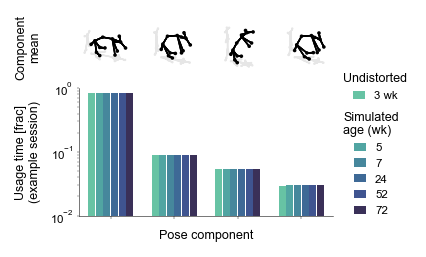

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f4.1_learns-morph/a-mixture-weights.pdf')

In [14]:
ex_weights = np.array([
    [params.pose.subj_weights[scan_dataset.session_id(f"{ref_age}wk_{a}bod_m0.{part}")] for part in '01']
    for a in [ref_age] + tgt_ages
])
comp_order = np.argsort(np.mean(ex_weights, axis = 0).mean(axis = 0))[::-1]
selected_comps = [0, 1, 2, 3]
inflated_comps = features.inflate(params.pose.means, cfg["features"])
# ordered_avg = np.mean(ex_weights[:, :, comp_order], axis = (1))
ordered_avg = np.mean(ex_weights[:, :, comp_order], axis = (1))

# 3d plotting with shadow
kws = lambda c, ps, ls: dict(
    armature = arms,
    elev = 30, 
    rot = -70,
    colors = np.array([c] * arms.n_kpts),
    point_size = ps,
    line_size = ls,
    boundary=False
)
dropz = lambda x, z: np.concatenate([x[:, :2], np.broadcast_to(x[:, 2].min() + z, x.shape[:-1] + (1,))], axis = -1) 
dropy = lambda x, y: np.concatenate([x[:, :1], np.broadcast_to(x[:, 1].max() + y, x.shape[:-1] + (1,)), x[:, 2:]], axis = -1)
dropx = lambda x, xx: np.concatenate([np.broadcast_to(x[:, 0].min() + xx, x.shape[:-1] + (1,)), x[:, 1:]], axis = -1)
plotdrop = lambda f, a, c, sm=1, lsm=1, shad=True, dropax=None, shadx=True, shady=True, shadz=True: [
    plot_mouse_3d(f, a, **kws(c, sm * 15, 1.5 * lsm))
    ] + [
    dropax := dropax if dropax is not None else a,
    ] + ([
    plot_mouse_3d(dropz(f, -7), dropax, **kws('.9', sm * 7, 1 * lsm)) if shadz else None,
    plot_mouse_3d(dropy(f, 10), dropax, **kws('.9', sm * 7, 1 * lsm)) if shady else None,
    plot_mouse_3d(dropx(f, -7), dropax, **kws('.9', sm * 7, 1 * lsm)) if shadx else None,
] if shad else [])

# ---- component means
n_select = len(selected_comps)
fig = plt.figure(figsize = (0.5 * (n_select) + 0.3, 1.8), dpi = 150)
gs_top_row = plt.GridSpec(2, n_select, height_ratios=[2, 2.5], hspace=0)
gs_main = plt.GridSpec(2, 1, height_ratios=[2, 3])

top_row = []
for i in range(n_select):
    ax = fig.add_subplot(gs_top_row[0, i], projection='3d')
    top_row.append(ax)
    if i > 0:
        ax.sharey(top_row[0])
    frame = inflated_comps[comp_order[selected_comps[i]]]
    plotdrop(frame, ax, 'k', sm = 0.2, lsm = 0.4, shady=False)

# ---- Total component usages

bar_width = 0.11
ax = fig.add_subplot(gs_main[1])
for i, (usage, a) in enumerate(zip(ordered_avg, [ref_age] + tgt_ages)):
    ax.bar(
        np.arange(params.pose.n_components) + 1.2 * viz.util.get_offsets(len(tgt_ages)+1, i),
        usage,
        width = bar_width,
        color = sim_pal[a],
        bottom=0,
        lw=0.,
    )

    # labels
    ax.bar([0], [np.nan], color = sim_pal[a], label = f"{a}")

ax.set_xticks(np.arange(params.pose.n_components))
ax.set_xticklabels([""] * params.pose.n_components)
ax.set_xlim(-0.5, params.pose.n_components - 1 + 0.5)
ax.set_ylim(1e-2, 1)
ax.set_ylabel("Usage time [frac]\n(example session)")
ax.set_yscale('log')
ax.set_xlabel("Pose component")
sns.despine(ax = ax)

plt.tight_layout()
tgt_lh = [(h, l) for h, l in zip(*ax.get_legend_handles_labels()) if l in tgt_ages]
ref_lh = [(h, f"{l} wk") for h, l in zip(*ax.get_legend_handles_labels()) if l == ref_age]
tgt_leg = viz.util.legend(ax, zip(*tgt_lh), loc = 'upper left', bbox_to_anchor = (1., 0.9), handlelength=1., title="Simulated\nage (wk)")
ref_leg = viz.util.legend(ax, zip(*ref_lh), loc = 'upper left', bbox_to_anchor = (1., 1.2), handlelength=1., title="Undistorted")
ax.add_artist(tgt_leg)
top_row[0].text2D(-0.95, 0.5, 'Component\nmean', ha='center', va='center', rotation='vertical', fontsize=6, transform=top_row[0].transAxes)

for leg in [tgt_leg, ref_leg]:
    leg.get_title().set_fontsize(6)
    leg.get_title().set_horizontalalignment('left')
plotter.finalize(fig, 'a-mixture-weights', despine = False, tight=False)

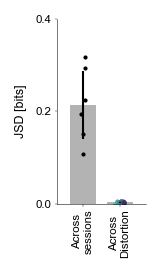

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f4.1_learns-morph/a-compare-weights.pdf')

In [15]:
ex_weights = np.array([[
    [params.pose.subj_weights[scan_dataset.session_id(f"{ref_age}wk_{a}bod_m{animal_id}.{part}")] for part in '01']
    for a in [ref_age] + tgt_ages] for animal_id in animal_ids
]).mean(axis = -2)



# ---- component means

fig, axes = plt.subplots(1, 1, figsize = (1.05, 1.8), dpi = 150)

# ---- Component usages vs reference

ax = axes
across_animal = [jensenshannon(ex_weights[j, 0], ex_weights[k, 0], base=2) for j, k in iit.combinations(animal_ids, 2)]
viz.util.grouped_stripplot(
    [np.array(across_animal)],
    x = [0],
    colors = mpl_col.to_rgba('k'),
    points_kw={'ms': 1},
    errorbar_kw=dict(ms=0)
)
ax.bar([0], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(across_animal), 0),)
to_ref = [[jensenshannon(ex_weights[j, i], ex_weights[j, 0], base=2) for j in animal_ids] for i, a in enumerate([ref_age] + tgt_ages)]
for i, (a, refdata) in enumerate(zip([ref_age] + tgt_ages, to_ref)):
    viz.util.grouped_stripplot(
        [np.array(refdata).ravel()],
        x = [1 + 0.5 * viz.util.get_offsets(len(tgt_ages)+1, i)],
        colors = sim_pal[a],
        points_kw={'ms': 1},
        jitter=0.0,
        errorbar=False,
        error=lambda x: viz.util.ci(x, np.nanmean, 0.95),
    )    
viz.util.grouped_stripplot(
    [np.array(to_ref).ravel()],
    x = [1],
    colors = mpl_col.to_rgba('k'),
    points=False,
    errorbar_kw=dict(ms=0),
    error=lambda x: viz.util.ci(x, np.nanmean, 0.95),
)
ax.bar([1], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(to_ref), 0),)
    
    
ax.set_ylabel("JSD [bits]")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Across\nsessions", "Across\nDistortion"], rotation=90)
ax.set_xlim(-0.7, 1.7)
ax.set_yticks([0, 0.2, 0.4])

plotter.finalize(fig, 'a-compare-weights', despine = False,)

### B. example equivalent poses

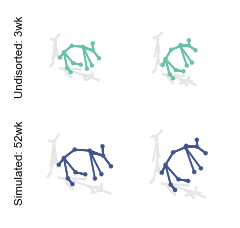

PosixPath('../../../../data_explore/plots/notebook/panels/v4/f4.1_learns-morph/b-equivalent-poses-anchor.pdf')

In [36]:
scan_align_meta = {'scale': np.array([-1. for _ in scan_dataset.sessions])}
for src_sess, splits in split_meta[1].items():
    for s in splits:
        scan_align_meta['scale'][scan_dataset.session_id(s)] = align_meta['scale'][dataset.session_id(src_sess)]

n_display=2
anchors = anchor_keypoints(
    params.morph,
    {},
    magnitudes=anchor_magnitudes(scan_dataset, params.morph, q = 0.1),
    config=cfg,
    session_meta=scan_dataset.session_meta,
)
anchors_scaled = anchor_keypoints(
    params.morph,
    scan_align_meta,
    magnitudes=anchor_magnitudes(scan_dataset, params.morph, q = 0.1),
    config=cfg,
    session_meta=scan_dataset.session_meta,
)


kws = lambda c, ps, ls: dict(
    armature = arms,
    elev = 30, 
    rot = -60,
    colors = np.array([c] * arms.n_kpts),
    point_size = ps,
    line_size = ls,
    boundary=False,
)
dropz = lambda x, z: np.concatenate([x[:, :2], np.broadcast_to(x[:, 2].min() + z, x.shape[:-1] + (1,))], axis = -1) 
dropy = lambda x, y: np.concatenate([x[:, :1], np.broadcast_to(x[:, 1].max() + y, x.shape[:-1] + (1,)), x[:, 2:]], axis = -1)
dropx = lambda x, xx: np.concatenate([np.broadcast_to(x[:, 0].min() + xx, x.shape[:-1] + (1,)), x[:, 1:]], axis = -1)
plotdrop = lambda f, a, c, sm=1, lsm=1, shad=True, dropax=None, shadx=True, shady=True, shadz=True: [
    plot_mouse_3d(f, a, **kws(c, sm * 15, 1.5 * lsm))
    ] + [
    dropax := dropax if dropax is not None else a,
    ] + ([
    plot_mouse_3d(dropz(f, -7), dropax, **kws('.9', sm * 7, 1 * lsm)) if shadz else None,
    plot_mouse_3d(dropy(f, 10), dropax, **kws('.9', sm * 7, 1 * lsm)) if shady else None,
    plot_mouse_3d(dropx(f, -7), dropax, **kws('.9', sm * 7, 1 * lsm)) if shadx else None,
] if shad else [])

gs = plt.GridSpec(2, n_display, height_ratios=[1, 1], wspace=0)
fig = plt.figure(figsize=(1.5, 1.5), dpi=150)
row0 = np.array([fig.add_subplot(gs[0, i], projection='3d') for i in range(n_display)])
row1 = np.array([fig.add_subplot(gs[1, i], projection='3d') for i in range(n_display)])

ref_body = scan_dataset.session_body_id(f'{ref_age}wk_{ref_age}bod_m0.0')
tgt_body = scan_dataset.session_body_id(f'{ref_age}wk_{tgt_age}bod_m0.0')
for i in range(n_display):
    row1[i].sharex(row0[i])
    row1[i].sharey(row0[i])
    row1[i].sharez(row0[i])

for i in range(n_display):
    plotdrop(anchors_scaled[ref_body, i], row0[i], ref_color, 0.3, 0.5, True, shady=False)
    plotdrop(anchors_scaled[tgt_body, i], row1[i], tgt_color, 0.3, 0.5, True, shady=False)

fig.tight_layout()
row0[0].text2D(-0.15, 0.55, f"Undisorted: {ref_age}wk", ha = 'center', va = 'center', rotation=90, size=5.5, transform=row0[0].transAxes)
row1[0].text2D(-0.15, 0.55, f"Simulated: {tgt_age}wk", ha = 'center', va = 'center', rotation=90, size=5.5, transform=row1[0].transAxes)

plotter.finalize(fig, 'b-equivalent-poses-anchor', tight=False)

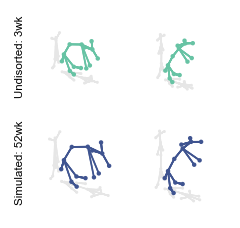

PosixPath('../../../../data_explore/plots/notebook/panels/v4/f4.1_learns-morph/b-equivalent-poses-comp.pdf')

In [37]:
scan_align_meta = {'scale': np.array([-1. for _ in scan_dataset.sessions])}
for src_sess, splits in split_meta[1].items():
    for s in splits:
        scan_align_meta['scale'][scan_dataset.session_id(s)] = align_meta['scale'][dataset.session_id(src_sess)]

n_display=2
comps_ref = features.inflate(params.pose.means, cfg["features"])
ref_sess = f'{ref_age}wk_{ref_age}bod_m0'
tgt_sess = f'{ref_age}wk_{tgt_age}bod_m0'
ref_body = dataset_feats.session_body_name(ref_sess)
tgt_body = dataset_feats.session_body_name(tgt_sess)
comps_tgt = features.inflate(model_util.apply_bodies(
    model.morph,
    merged_params,
    single_session_dataset(params.pose.means, ref_body, ref_sess, dataset_feats.session_meta),
    {ref_sess: tgt_body},
).data, cfg["features"])

comps_tgt_scaled = alignment._inverse_align_scales(
    comps_tgt, np.full([len(comps_tgt)], align_meta['scale'][dataset_feats.session_id(tgt_sess)]), stacked=True
)
comps_ref_scaled = alignment._inverse_align_scales(
    comps_ref, np.full([len(comps_ref)], align_meta['scale'][dataset_feats.session_id(ref_sess)]), stacked=True
)



kws = lambda c, ps, ls: dict(
    armature = arms,
    elev = 30, 
    rot = -60,
    colors = np.array([c] * arms.n_kpts),
    point_size = ps,
    line_size = ls,
    boundary=False,
)
dropz = lambda x, z: np.concatenate([x[:, :2], np.broadcast_to(x[:, 2].min() + z, x.shape[:-1] + (1,))], axis = -1) 
dropy = lambda x, y: np.concatenate([x[:, :1], np.broadcast_to(x[:, 1].max() + y, x.shape[:-1] + (1,)), x[:, 2:]], axis = -1)
dropx = lambda x, xx: np.concatenate([np.broadcast_to(x[:, 0].min() + xx, x.shape[:-1] + (1,)), x[:, 1:]], axis = -1)
plotdrop = lambda f, a, c, sm=1, lsm=1, shad=True, dropax=None, shadx=True, shady=True, shadz=True: [
    plot_mouse_3d(f, a, **kws(c, sm * 15, 1.5 * lsm))
    ] + [
    dropax := dropax if dropax is not None else a,
    ] + ([
    plot_mouse_3d(dropz(f, -7), dropax, **kws('.9', sm * 7, 1 * lsm)) if shadz else None,
    plot_mouse_3d(dropy(f, 10), dropax, **kws('.9', sm * 7, 1 * lsm)) if shady else None,
    plot_mouse_3d(dropx(f, -7), dropax, **kws('.9', sm * 7, 1 * lsm)) if shadx else None,
] if shad else [])

gs = plt.GridSpec(2, n_display, height_ratios=[1, 1], wspace=0)
fig = plt.figure(figsize=(1.5, 1.5), dpi=150)
row0 = np.array([fig.add_subplot(gs[0, i], projection='3d') for i in range(n_display)])
row1 = np.array([fig.add_subplot(gs[1, i], projection='3d') for i in range(n_display)])


for i in range(n_display):
    row1[i].sharex(row0[i])
    row1[i].sharey(row0[i])
    row1[i].sharez(row0[i])

for i in range(n_display):
    plotdrop(comps_ref_scaled[i], row0[i], ref_color, 0.3, 0.5, True, shady=False)
    plotdrop(comps_tgt_scaled[i], row1[i], tgt_color, 0.3, 0.5, True, shady=False)

fig.tight_layout()
row0[0].text2D(-0.15, 0.55, f"Undisorted: {ref_age}wk", ha = 'center', va = 'center', rotation=90, size=5.5, transform=row0[0].transAxes)
row1[0].text2D(-0.15, 0.55, f"Simulated: {tgt_age}wk", ha = 'center', va = 'center', rotation=90, size=5.5, transform=row1[0].transAxes)

plotter.finalize(fig, 'b-equivalent-poses-comp', tight=False)

### C. Normalizes bone lengths


##### Bone length distributions in observation and canonical spaces

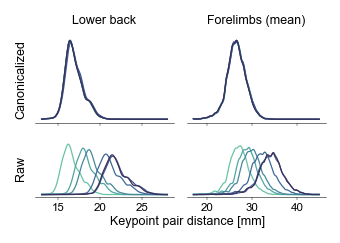

PosixPath('../../../../data_explore/plots/notebook/panels/v4/f4.1_learns-morph/c-bls-raw-vs-canon.pdf')

In [99]:
rescale = True


loback_ix = bone_names.index('hips-back') if 'hips-back' in bone_names else bone_names.index('back-hips')
# hiback_ix = bone_names.index('back-shldr') if 'back-shldr' in bone_names else bone_names.index('shldr-back')
lfpaw_ix = bone_names.index('lf_foot-shldr') if 'lf_foot-shldr' in bone_names else bone_names.index('shldr-lf_foot')
rfpaw_ix = bone_names.index('rf_foot-shldr') if 'rf_foot-shldr' in bone_names else bone_names.index('shldr-rf_foot')

# ---- canonicalize, compute bone lengths of canonical and raw
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta={'scale': np.array(align_meta['scale'])})
bls_canon, bls_raw, _ = canonicalized_raw_bls(canonicalized, raw, dataset.sessions, parts = [''], sep = '')

loback_canon = {k: v[:, loback_ix] for k, v in bls_canon.items()}
loback_raw = {k: v[:, loback_ix] for k, v in bls_raw.items()}
# hiback_canon = {k: v[:, hiback_ix] for k, v in bls_canon.items()}
# hiback_raw = {k: v[:, hiback_ix] for k, v in bls_raw.items()}
flimb_canon = {k: v[:, [lfpaw_ix, rfpaw_ix]].mean(axis = 1) for k, v in bls_canon.items()}
flimb_raw = {k: v[:, [lfpaw_ix, rfpaw_ix]].mean(axis = 1) for k, v in bls_raw.items()}


# ---- plot bone length distributions
fig, ax = plt.subplots(2, 2, figsize=(2.25, 1.5), sharex='col', sharey='col', height_ratios = [1.5, 1], dpi=150)
for group, color in zip([ref_age] + tgt_ages, [ref_color] + tgt_colors):

    loback_x = np.linspace(13, 28, 200)
    flimb_x = np.linspace(17, 45, 200)

    kw = dict(lw = 0.6, color = color, label = group)
    ax[0, 0].plot(*viz.util.kde(loback_canon[group], 0.2, 500, 5, True, loback_x), **kw)
    # ax[0, 1].plot(*viz.util.kde(hiback_canon[group], bw = 0.2, density=True, eval_x=hiback_x), **kw)
    ax[0, 1].plot(*viz.util.kde(flimb_canon[group], 0.26,500, 5, True, flimb_x), **kw)
    ax[1, 0].plot(*viz.util.kde(loback_raw[group], 0.2, 500, 5, True, loback_x), **kw)
    # ax[1, 1].plot(*viz.util.kde(hiback_raw[group], bw = 0.2, density=True, eval_x=hiback_x), **kw)
    ax[1, 1].plot(*viz.util.kde(flimb_raw[group], 0.26,500, 5, True, flimb_x), **kw)

for a in ax.ravel():
    a.set_yticks([])
    a.spines['left'].set_visible(False)

ax[0, 0].set_ylabel("Canonicalized")
ax[1, 0].set_ylabel("Raw")
# ax[1, 0].set_xlabel(" " * 25 + "Keypoint pair distance [mm]")
fig.text(0.55, 0.02, "Keypoint pair distance [mm]", ha='center', va='center')
ax[0, 0].set_title("Lower back")
ax[0, 1].set_title("Forelimbs (mean)")
# ax[0, 1].set_title("Upper back")

plotter.finalize(fig, 'c-bls-raw-vs-canon', despine=False)




##### Various definitions of learned ratio compared against applied distortion

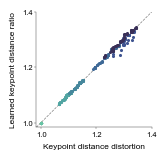

PosixPath('../../../../data_explore/plots/notebook/panels/v4/f4.1_learns-morph/c-anchor-poses-bls-vs-applied.pdf')

In [34]:
rescale = True
sessions = dataset_feats.sessions
ref_sess = f"{ref_age}wk_{ref_age}bod_m0"
pairs = {
    s: re.sub(r"\d+bod", f"{ref_age}bod", s)
    for s in sessions
    if s != ref_sess
}

# ---- get rescaled raw data and anchor poses, compute paired bone length ratios
_align_meta = {'scale': np.array(align_meta['scale'])}
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)
anchors = anchor_keypoints(  # shape (n_session, n_anchor, n_kpt, 3)
    merged_params,
    _align_meta if rescale else {},
    magnitudes=anchor_magnitudes(dataset_feats, merged_params, q=0.1),
    config=cfg,
    session_meta=dataset_feats.session_meta,
)

raw_bls = {s: _bone_lengths(raw.get_session(s), arms) for s in sessions}
raw_ratios = {s: raw_bls[s] / raw_bls[pairs[s]] for s in pairs}

anchor_bls = {
    s: _bone_lengths(anchors[dataset_feats.session_id(s)], arms) for s in sessions
}
anchor_ratios = {s: anchor_bls[s] / anchor_bls[pairs[s]] for s in pairs}




# --- plot ratio in raw vs ratio in anchor poses
fig, ax = plt.subplots(figsize=(1.5, 1.5))

for s in pairs:
    group = re.search(r"(\d+)bod", s).group(1)
    group_pal = {ref_age: ref_color, **{a: c for a, c in zip(tgt_ages, tgt_colors)}}
    anchor_pal = Colormap('husl')(np.linspace(0, 1, anchors.shape[1]))
    # for i_a in range(anchors.shape[1]):
    ax.scatter(raw_ratios[s].mean(axis = 0), anchor_ratios[s].mean(axis = 0), color=group_pal[group], s=2, label=group)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
min_, max_ = min(xmin, ymin, 1.), max(xmax, ymax, 1.4)
ax.set_xlim(min_, max_)
ax.set_ylim(min_, max_)
ax.plot([min_, max_], [min_, max_], color='.5', lw=0.5, ls='--', zorder=-1, )
ax.set_aspect(1.)
ax.set_ylabel("Learned keypoint distance ratio")
ax.set_yticks([1., 1.2, 1.4])
ax.set_xticks([1., 1.2, 1.4])
ax.set_xlabel("Keypoint distance distortion")
hl = zip(*sorted(zip(*viz.util.unique_handles(ax)), key=lambda x: int(x[1])))
# leg = viz.util.legend(ax, hl, loc='upper left', bbox_to_anchor=(1.1, 1.), frameon=False, ncol=2)
# for h in leg.legend_handles:
    # h.set_sizes([6])

plotter.finalize(fig, 'c-anchor-poses-bls-vs-applied', tight=False, despine=False)

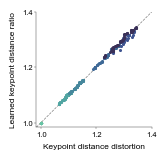

PosixPath('../../../../data_explore/plots/notebook/panels/v4/f4.1_learns-morph/c-anchor-poses-bls-vs-applied.pdf')

In [81]:
rescale = True
sessions = dataset.sessions
parts = "01"
pairs = {
    s: re.sub(r"\d+bod", f"{ref_age}bod", s)
    for s in sessions
    if s != ref_sess
}

# ---- get rescaled raw data and anchor poses, compute paired bone length ratios

_, raw, scan_align_meta = canonicalized_and_raw(scan_dataset, params, dataset, rescale=rescale, scale_to=scale_to)
anchors = anchor_keypoints(  # shape (n_session, n_anchor, n_kpt, 3)
    params.morph,
    scan_align_meta if rescale else {},
    magnitudes=anchor_magnitudes(scan_dataset, params.morph, q=0.1),
    config=cfg,
    session_meta=scan_dataset.session_meta,
)

raw_bls = {
    s: np.concatenate(
        [_bone_lengths(raw.get_session(f"{s}.{part}"), arms) for part in parts]
    )
    for s in sessions
}
raw_ratios = {s: raw_bls[s] / raw_bls[pairs[s]] for s in pairs}

anchor_bls = {
    s: np.mean(
        [_bone_lengths(anchors[scan_dataset.session_id(f"{s}.{part}")], arms) for part in parts],
        axis = 0
    )
    for s in sessions
}
anchor_ratios = {s: anchor_bls[s] / anchor_bls[pairs[s]] for s in pairs}




# --- plot ratio in raw vs ratio in anchor poses
fig, ax = plt.subplots(figsize=(1.5, 1.5))

for s in pairs:
    group = re.search(r"(\d+)bod", s).group(1)
    group_pal = {ref_age: ref_color, **{a: c for a, c in zip(tgt_ages, tgt_colors)}}
    anchor_pal = Colormap('husl')(np.linspace(0, 1, anchors.shape[1]))
    # for i_a in range(anchors.shape[1]):
    ax.scatter(raw_ratios[s].mean(axis = 0), anchor_ratios[s].mean(axis = 0), color=group_pal[group], s=2, label=group)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
min_, max_ = min(xmin, ymin, 1.), max(xmax, ymax, 1.4)
ax.set_xlim(min_, max_)
ax.set_ylim(min_, max_)
ax.plot([min_, max_], [min_, max_], color='.5', lw=0.5, ls='--', zorder=-1, )
ax.set_aspect(1.)
ax.set_ylabel("Learned keypoint distance ratio")
ax.set_yticks([1., 1.2, 1.4])
ax.set_xticks([1., 1.2, 1.4])
ax.set_xlabel("Keypoint distance distortion")
hl = zip(*sorted(zip(*viz.util.unique_handles(ax)), key=lambda x: int(x[1])))
# leg = viz.util.legend(ax, hl, loc='upper left', bbox_to_anchor=(1.1, 1.), frameon=False, ncol=2)
# for h in leg.legend_handles:
    # h.set_sizes([6])

plotter.finalize(fig, 'c-anchor-poses-bls-vs-applied', tight=False, despine=False)

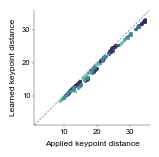

PosixPath('../../../../data_explore/plots/notebook/panels/v4/f4.1_learns-morph/c-anchor-poses-bls-vs-applied-unnormed.pdf')

In [79]:
rescale = True
sessions = dataset.sessions
parts = "01"
pairs = {
    s: re.sub(r"\d+bod", f"{ref_age}bod", s)
    for s in sessions
    if s != ref_sess
}

# ---- get rescaled raw data and anchor poses, compute paired bone length ratios

_, raw, scan_align_meta = canonicalized_and_raw(scan_dataset, params, dataset, rescale=rescale, scale_to=scale_to)
anchors = anchor_keypoints(  # shape (n_session, n_anchor, n_kpt, 3)
    params.morph,
    scan_align_meta if rescale else {},
    magnitudes=anchor_magnitudes(scan_dataset, params.morph, q=0.1),
    config=cfg,
    session_meta=scan_dataset.session_meta,
)

raw_bls = {
    s: np.concatenate(
        [_bone_lengths(raw.get_session(f"{s}.{part}"), arms) for part in parts]
    )
    for s in sessions
}
raw_ratios = {s: raw_bls[s] for s in pairs}

anchor_bls = {
    s: np.mean(
        [_bone_lengths(anchors[scan_dataset.session_id(f"{s}.{part}")], arms) for part in parts],
        axis = 0
    )
    for s in sessions
}
anchor_ratios = {s: anchor_bls[s] for s in pairs}




# --- plot ratio in raw vs ratio in anchor poses
fig, ax = plt.subplots(figsize=(1.5, 1.5))

for s in pairs:
    group = re.search(r"(\d+)bod", s).group(1)
    group_pal = {ref_age: ref_color, **{a: c for a, c in zip(tgt_ages, tgt_colors)}}
    anchor_pal = Colormap('husl')(np.linspace(0, 1, anchors.shape[1]))
    # for i_a in range(anchors.shape[1]):
    ax.scatter(raw_ratios[s].mean(axis = 0), anchor_ratios[s].mean(axis = 0), color=group_pal[group], s=2, label=group)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
min_, max_ = min(xmin, ymin, 1.), max(xmax, ymax, 1.4)
ax.set_xlim(min_, max_)
ax.set_ylim(min_, max_)
ax.plot([min_, max_], [min_, max_], color='.5', lw=0.5, ls='--', zorder=-1, )
ax.set_aspect(1.)
ax.set_ylabel("Learned keypoint distance")
ax.set_xlabel("Applied keypoint distance")

plotter.finalize(fig, 'c-anchor-poses-bls-vs-applied-unnormed', tight=False, despine=False)

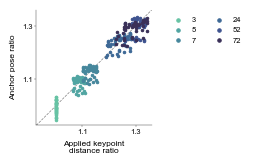

PosixPath('../../../../data_explore/plots/notebook/panels/v4/f4.1_learns-morph/c-learned-bls-vs-applied.pdf')

In [64]:
rescale = True
sessions = dataset.sessions
parts = "01"
pairs = {
    s: re.sub(r"\d+bod", f"{ref_age}bod", s)
    for s in sessions
    if s != ref_sess
}

# ---- get rescaled raw data and anchor poses, compute paired bone length ratios

_, raw, scan_align_meta = canonicalized_and_raw(scan_dataset, params, dataset, rescale=rescale, scale_to=scale_to)
anchors = anchor_keypoints(  # shape (n_session, n_anchor, n_kpt, 3)
    params.morph,
    scan_align_meta if rescale else {},
    magnitudes=anchor_magnitudes(scan_dataset, params.morph, q=0.1),
    config=cfg,
    session_meta=scan_dataset.session_meta,
)

raw_bls = {
    s: np.concatenate(
        [_bone_lengths(raw.get_session(f"{s}.{part}"), arms) for part in parts]
    )
    for s in sessions
}
raw_ratios = {s: raw_bls[s] / raw_bls[pairs[s]] for s in pairs}

canon_bls = {
    s: np.concatenate(
        [_bone_lengths(canonicalized.get_session(f"{s}.{part}"), arms) for part in parts]
    )
    for s in sessions
}
learned_ratios = {s: raw_bls[s] / canon_bls[s] for s in pairs}




# --- plot ratio in raw vs ratio in anchor poses
fig, ax = plt.subplots(figsize=(1.5, 1.5))

for s in pairs:
    group = re.search(r"(\d+)bod", s).group(1)
    group_pal = {ref_age: ref_color, **{a: c for a, c in zip(tgt_ages, tgt_colors)}}
    anchor_pal = Colormap('husl')(np.linspace(0, 1, anchors.shape[1]))
    ax.scatter(raw_ratios[s].mean(axis = 0), learned_ratios[s].mean(axis = 0), color=group_pal[group], s=3, label=group)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
min_, max_ = min(xmin, ymin), max(xmax, ymax)
ax.set_xlim(min_, max_)
ax.set_ylim(min_, max_)
ax.plot([min_, max_], [min_, max_], color='.5', lw=0.5, ls='--', zorder=-1, )
ax.set_aspect(1.)
ax.set_ylabel("Anchor pose ratio")
ax.set_yticks([1.1, 1.3])
ax.set_xticks([1.1, 1.3])
ax.set_xlabel("Applied keypoint\ndistance ratio")
hl = zip(*sorted(zip(*viz.util.unique_handles(ax)), key=lambda x: int(x[1])))
leg = viz.util.legend(ax, hl, loc='upper left', bbox_to_anchor=(1.1, 1.), frameon=False, ncol=2)
for h in leg.legend_handles:
    h.set_sizes([6])

plotter.finalize(fig, 'c-learned-bls-vs-applied', tight=False, despine=False)

(4, 14, 3)


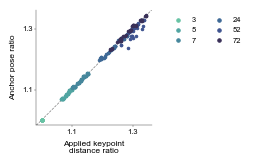

PosixPath('../../../../data_explore/plots/notebook/panels/v4/f4.1_learns-morph/c-comp-bls-vs-applied.pdf')

In [78]:
rescale = True
sessions = dataset.sessions
parts = "01"
pairs = {
    s: re.sub(r"\d+bod", f"{ref_age}bod", s)
    for s in sessions
    if s != ref_sess
}

# ---- get rescaled raw data and anchor poses, compute paired bone length ratios

raw_bls = {
    s: np.concatenate(
        [_bone_lengths(raw.get_session(f"{s}.{part}"), arms) for part in parts]
    )
    for s in sessions
}
raw_ratios = {s: raw_bls[s] / raw_bls[pairs[s]] for s in pairs}

comps_ref = features.inflate(params.pose.means, cfg["features"])
# ref_body = dataset_feats.session_body_name(ref_sess)
comps_tgt = {
    s: alignment._inverse_align_scales(
        features.inflate(model_util.apply_bodies(
            model.morph,
            merged_params,
            single_session_dataset(params.pose.means, ref_body, ref_sess, dataset_feats.session_meta),
            {ref_sess: dataset_feats.session_body_name(s)},
        ).data, cfg["features"]),
        np.full([params.pose.n_components], align_meta['scale'][dataset_feats.session_id(s)]),
        stacked=True
    )
    for s in dataset_feats.sessions
}
print(comps_tgt['3wk_24bod_m0'].shape)
comp_bls = {s: _bone_lengths(comps_tgt[s], arms) for s in dataset_feats.sessions}
comp_ratios = {s: comp_bls[s] / comp_bls[pairs[s]] for s in pairs}




# --- plot ratio in raw vs ratio in anchor poses
fig, ax = plt.subplots(figsize=(1.5, 1.5))

for s in pairs:
    group = re.search(r"(\d+)bod", s).group(1)
    group_pal = {ref_age: ref_color, **{a: c for a, c in zip(tgt_ages, tgt_colors)}}
    # for j in range(params.pose.n_components):
    ax.scatter(raw_ratios[s].mean(axis = 0), comp_ratios[s].mean(axis = 0), color=group_pal[group], s=3, label=group)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
min_, max_ = min(xmin, ymin), max(xmax, ymax)
ax.set_xlim(min_, max_)
ax.set_ylim(min_, max_)
ax.plot([min_, max_], [min_, max_], color='.5', lw=0.5, ls='--', zorder=-1, )
ax.set_aspect(1.)
ax.set_ylabel("Anchor pose ratio")
ax.set_yticks([1.1, 1.3])
ax.set_xticks([1.1, 1.3])
ax.set_xlabel("Applied keypoint\ndistance ratio")
hl = zip(*sorted(zip(*viz.util.unique_handles(ax)), key=lambda x: int(x[1])))
leg = viz.util.legend(ax, hl, loc='upper left', bbox_to_anchor=(1.1, 1.), frameon=False, ncol=2)
for h in leg.legend_handles:
    h.set_sizes([6])

plotter.finalize(fig, 'c-comp-bls-vs-applied', tight=False, despine=False)

### D. Relative growth rates are normalized

#### Growth rates

0.15565372016274998


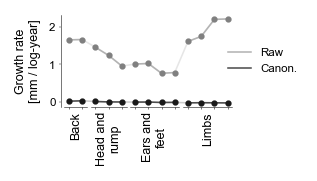

PosixPath('../../../../data_explore/plots/notebook/panels/v4/f4.1_learns-morph/d-rel-growth-rates.pdf')

In [194]:
rescale = True
group_order = [ref_age] + tgt_ages


sessions = dataset.sessions
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)
bls_canon, bls_raw, groups = canonicalized_raw_bls(canonicalized, raw, sessions, parts = [''], sep = '')



cov = lambda x, y: (x * y).mean(axis=-1) - x.mean(axis=-1) * y.mean(axis=-1)
coef = lambda a, b: cov(a, b) / cov(a, a)
coefs_raw = np.zeros([len(bone_names)] * 2)
coefs_canon = np.zeros([len(bone_names)] * 2)


for (r, r_ix), (c, c_ix) in iit.product(enumerate(bone_ix_order), enumerate(bone_ix_order)):
    # if r == c:
        # continue
    logage = np.log([int(g) for g in group_order])

    rto_canon = np.array([
        bls_canon[g][:, c_ix].mean() #/ bls_canon[g][:, r_ix].mean()
        for g in group_order
    ])
    coefs_canon[r, c] = coef(logage, rto_canon)

    rto_raw = np.array([
        bls_raw[g][:, c_ix].mean() #/ bls_raw[g][:, r_ix].mean()
        for g in group_order
    ])
    coefs_raw[r, c] = coef(logage, rto_raw)
    
fig, ax = plt.subplots(1, 1, figsize = (1.5, 0.8), dpi=150)
ax.plot(coefs_raw[0, :], '-', color = '.9', lw = 0.75, zorder = -2)
ax.plot(coefs_canon[0, :], '-', color = '.8', lw = 0.75, zorder = -2)
for bone_group in bone_groups:
    g = np.arange(bone_group[0], bone_group[1] + 1)
    ax.plot(g, coefs_raw[0, g], '-', color = '.7', lw = 0.75, label = 'Raw')
    ax.plot(g, coefs_canon[0, g], '-', color = '.3', lw = 0.75, label = 'Canon.')

ax.plot(coefs_raw[0, :], 'o', color = '.5', ms = 2)
ax.plot(coefs_canon[0, :], 'o', color = colors.neutral, ms = 2)
viz.util.legend(ax, viz.util.unique_handles(ax), bbox_to_anchor = (0.9, 0.5))

# ax.set_xticks(np.arange(len(bone_order)))
# ax.set_xticklabels(bone_name_order, rotation = 90, fontsize = 6)
ax.set_xticks([])
ax.spines['bottom'].set_visible(False)
ax.set_ylabel("Growth rate\n[mm / log-year]")
# viz.util.legend(ax, loc = 'upper left', fontsize = 6, frameon = False)
# ax.set_yticks([0, 3e-2, 6e-2])


ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax)
for bg, n in zip(bone_groups, bone_group_names):
    ax.add_artist(
        mpl.lines.Line2D(
            [bg[0] - 0.35, bg[1] + 0.35],
            [ymin, ymin],
            color="k",
            lw=0.25,
            clip_on=False,
        )
    )
    ax.add_artist(
        mpl.text.Text(
            (bg[0] + bg[1]) / 2,
            -0.05,
            n,
            ha="center",
            va="top",
            clip_on=False,
            fontsize=6,
            rotation=90,
            transform=mpl.transforms.blended_transform_factory(
                ax.transData, ax.transAxes
            ),
        )
    )
# convert inches to data coordinates
# (1 mm = 0.0393701 inches)
mm_to_data_y = ax.transData.inverted().transform([0, fig.dpi_scale_trans.transform((0, 0.039))[1]])[1] - ax.transData.inverted().transform([0, fig.dpi_scale_trans.transform((0, 0))[1]])[1]
print(mm_to_data_y)
for x in range(0, len(bone_names)):
    ax.add_artist(
        mpl.lines.Line2D(
            [x, x],
            [ymin, ymin-mm_to_data_y*0.3],
            color="k",
            lw=0.25,
            clip_on=False,
            solid_capstyle="butt",
        )
    )


plotter.finalize(fig, 'd-rel-growth-rates', tight=False, despine=False)

#### Head-torso ratio

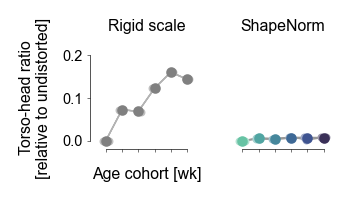

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f4.1_learns-morph/d-torso-head-ratio.pdf')

In [26]:

head_ix = [bone_names.index(short_names.inverse[b]) for b in ['head', 'neck', 'rump']]
back_ix = [bone_names.index(short_names.inverse[b]) for b in ['lo back', 'hi back']]


rescale = True
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, _, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)
raw, _ = unalign_scales(_align_meta, dataset_versions['aligned'], None, None)

bls_canon = {s: np.array(_bone_lengths(canonicalized.get_session(s), arms).mean(axis = 0)) for s in dataset_feats.sessions}
bls_raw = {s: np.array(_bone_lengths(raw.get_session(s), arms).mean(axis = 0)) for s in dataset_feats.sessions}

rto_canon = {s: (bls_canon[s][back_ix].mean(axis = 0)) / bls_canon[s][head_ix].mean(axis = 0) for s in dataset_feats.sessions}
rto_raw = {s: (bls_raw[s][back_ix].mean(axis = 0)) / bls_raw[s][head_ix].mean(axis = 0) for s in dataset_feats.sessions}
ages = [ref_age] + tgt_ages
age_groups = {a: [s for s in dataset_feats.sessions if re.search(r"(\d+)bod", s).group(1) == a] for a in ages}
rto_canon = [np.array([rto_canon[s] for s in age_groups[a]]) for a in ages]
rto_raw = [np.array([rto_raw[s] for s in age_groups[a]]) for a in ages]
rto_canon = [r - rto_canon[0] for r in rto_canon]
rto_raw = [r - rto_raw[0] for r in rto_raw]

kw = dict(
    error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
    jitter = 0.2,
    lighten_points = 0.5,
    lim_buffer = 1,
    offset=False,
    xticks=ages,
)

fig, ax = plt.subplots(1, 2, figsize = (1.7, 0.7), dpi=190)
for i in range(4):
    ax[0].plot([r[i] for r in rto_raw], '-', lw = 0.5, color = '.7')
    ax[1].plot([r[i] for r in rto_canon], '-', lw = 0.5, color = '.6')
viz.util.grouped_stripplot(viz.util.expand_groups(rto_raw, ages), x = np.arange(len(ages)), ax = ax[0], colors='.5', **kw)
viz.util.grouped_stripplot(viz.util.expand_groups(rto_canon, ages), x = np.arange(len(ages)), ax = ax[1], colors=sim_pal, **kw)
for a in ax:
    a.set_ylim(-0.02, 0.22)
    a.set_xticklabels([""] * len(ages))

ax[1].set_yticks([])
    
ax[0].set_ylabel('Torso-head ratio\n[relative to undistorted]')
ax[0].set_xlabel('Age cohort [wk]')
ax[0].set_title("Rigid scale")
ax[1].set_title("ShapeNorm")
sns.despine(ax = ax[0], trim = True)
sns.despine(ax = ax[1], trim = True, left=True)

plotter.finalize(fig, 'd-torso-head-ratio', tight=False, despine=False)

#### Experiments towards realizing that you need to normalize by animal and not reduce dimension

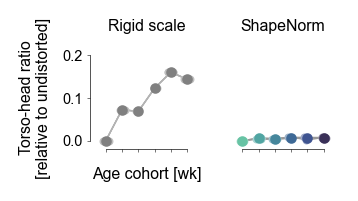

In [25]:


head_ix = [bone_names.index(short_names.inverse[b]) for b in ['head', 'neck', 'rump']]
back_ix = [bone_names.index(short_names.inverse[b]) for b in ['lo back', 'hi back']]


rescale = True
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, _, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)
raw, _ = unalign_scales(_align_meta, dataset_versions['aligned'], None, None)

bls_canon = {s: np.array(_bone_lengths(canonicalized.get_session(s), arms).mean(axis = 0)) for s in dataset_feats.sessions}
bls_raw = {s: np.array(_bone_lengths(raw.get_session(s), arms).mean(axis = 0)) for s in dataset_feats.sessions}

rto_canon = {s: (bls_canon[s][back_ix].mean(axis = 0)) / bls_canon[s][head_ix].mean(axis = 0) for s in dataset_feats.sessions}
rto_raw = {s: (bls_raw[s][back_ix].mean(axis = 0)) / bls_raw[s][head_ix].mean(axis = 0) for s in dataset_feats.sessions}
ages = [ref_age] + tgt_ages
age_groups = {a: [s for s in dataset_feats.sessions if re.search(r"(\d+)bod", s).group(1) == a] for a in ages}
rto_canon = [np.array([rto_canon[s] for s in age_groups[a]]) for a in ages]
rto_raw = [np.array([rto_raw[s] for s in age_groups[a]]) for a in ages]
rto_canon = [r - rto_canon[0] for r in rto_canon]
rto_raw = [r - rto_raw[0] for r in rto_raw]

kw = dict(
    error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
    jitter = 0.2,
    lighten_points = 0.5,
    lim_buffer = 1,
    offset=False,
    xticks=ages,
)

fig, ax = plt.subplots(1, 2, figsize = (1.7, 0.7), dpi=190)
for i in range(4):
    ax[0].plot([r[i] for r in rto_raw], '-', lw = 0.5, color = '.7')
    ax[1].plot([r[i] for r in rto_canon], '-', lw = 0.5, color = '.6')
viz.util.grouped_stripplot(viz.util.expand_groups(rto_raw, ages), x = np.arange(len(ages)), ax = ax[0], colors='.5', **kw)
viz.util.grouped_stripplot(viz.util.expand_groups(rto_canon, ages), x = np.arange(len(ages)), ax = ax[1], colors=sim_pal, **kw)
for a in ax:
    a.set_ylim(-0.02, 0.22)
    a.set_xticklabels([""] * len(ages))

ax[1].set_yticks([])
    
ax[0].set_ylabel('Torso-head ratio\n[relative to undistorted]')
ax[0].set_xlabel('Age cohort [wk]')
ax[0].set_title("Rigid scale")
ax[1].set_title("ShapeNorm")
sns.despine(ax = ax[0], trim = True)
sns.despine(ax = ax[1], trim = True, left=True)

plotter.finalize(fig, None, tight=False, despine=False)

ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 2 dimension(s) and the array at index 1 has 1 dimension(s)

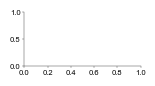

In [10]:
rescale=False
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)
# bls_canon = {s: _bone_lengths(canonicalized.get_session(s), arms).mean(axis = 0) for s in dataset_feats.sessions}
bls_raw = {s: _bone_lengths(raw.get_session(s), arms) for s in dataset_feats.sessions}

# tl_canon = {s: l[bone_names.index('back-hips')] + l[bone_names.index('shldr-back')] for s, l in bls_canon.items()}
rl_raw = {s: l[bone_names.index('back-hips')] + l[bone_names.index('shldr-back')] for s, l in bls_raw.items()}
# hl_canon = {s: l[bone_names.index('nose-head')] for s, l in bls_canon.items()}
hl_raw = {s: l[bone_names.index('nose-head')] for s, l in bls_raw.items()}
# rto_canon = {s: tl_canon[s] / hl_canon[s] for s in dataset_feats.sessions}
rto_raw = {s: rl_raw[s] / hl_raw[s] for s in dataset_feats.sessions}
ages = [ref_age] + tgt_ages
age_groups = {a: [s for s in dataset.sessions if re.search(r"(\d+)bod", s).group(1) == a] for a in ages}
# rto_canon = [np.array([rto_canon[s] for s in age_groups[a]]) for a in ages]
rto_raw = [np.array([rto_raw[s] for s in age_groups[a]]) for a in ages]



kw = dict(
    error = lambda a, **kw: viz.util.ci(a, level=0.95, n=1000),
    jitter = 0.2,
    lighten_points = 0.5,
    lim_buffer = 1,
    offset=False,
    xticks=ages,
)

fig, ax = plt.subplots(figsize = (1.5, 0.7))
viz.util.grouped_stripplot(viz.util.expand_groups(rto_raw, ages), ax = ax, colors='.6', **kw)
# viz.util.grouped_stripplot(viz.util.expand_groups(rto_canon, ages), ax = ax, colors=sim_pal, **kw)
ax.set_ylabel('Ratio')
ax.set_xlabel('Age cohort [wk]')
ax.set_ylim(2, 3)
sns.despine(ax = ax, trim = True)

plotter.finalize(fig, "d-torso-head-rto", save=True, despine=False)

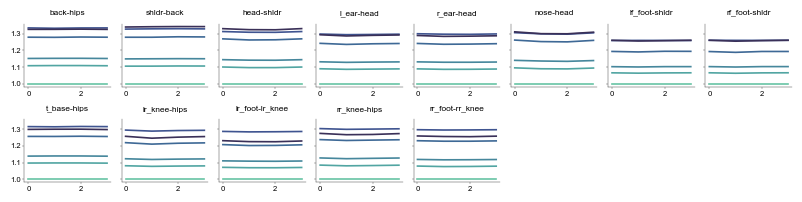

In [45]:

rescale=True
_align_meta = {'scale': np.array(align_meta['scale'])}
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)

bls_raw = {s: _bone_lengths(raw.get_session(s), arms) for s in dataset_feats.sessions}
age_groups = {a: [s for s in dataset_feats.sessions if re.search(r"(\d+)bod", s).group(1) == a] for a in ages}

fig, axes, ax_grid = viz.util.flat_grid(len(bone_names), 8, (1, 1), sharex=False, sharey=True)
for ax, b in zip(axes, bone_names):
    ax.set_title(b)
    for a, g in age_groups.items():
        ax.plot(np.array([bls_raw[s][:, bone_names.index(b)].mean() for s in g]) / np.array([bls_raw[s][:, bone_names.index(b)].mean() for s in age_groups['3']]), color=sim_pal[a])
fig.tight_layout()  

[('lo back', 'back-hips'), ('hi back', 'shldr-back'), ('neck', 'head-shldr'), ('L ear', 'l_ear-head'), ('R ear', 'r_ear-head'), ('head', 'nose-head'), ('R forelimb', 'lf_foot-shldr'), ('L forelimb', 'rf_foot-shldr'), ('rump', 't_base-hips'), ('L hindlimb', 'lr_knee-hips'), ('L foot', 'lr_foot-lr_knee'), ('R hindlimb', 'rr_knee-hips'), ('R foot', 'rr_foot-rr_knee')]


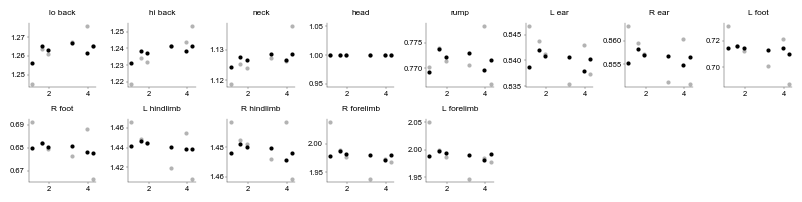

In [22]:
rescale = True
group_order = [ref_age] + tgt_ages

sessions = dataset.sessions
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)
bls_canon, bls_raw, groups = canonicalized_raw_bls(canonicalized, raw, sessions, parts = [''], sep = '')

head_ix = bone_names.index[short_names.inverse('head')]

cov = lambda x, y: (x * y).mean(axis=-1) - x.mean(axis=-1) * y.mean(axis=-1)
coef = lambda a, b: cov(a, b) / cov(a, a)
coefs_raw = np.zeros([len(bone_names)] * 2)
coefs_canon = np.zeros([len(bone_names)] * 2)


fig, axes, ax_grid = viz.util.flat_grid(len(bone_ix_order), 8, (1, 1), sharex=False, sharey=False)

for (r, r_ix), (c, (c_ix, ax)) in iit.product(enumerate(bone_ix_order), enumerate(zip(bone_ix_order, axes))):
    # if r == c:
        # continue
    logage = np.log([int(g) for g in group_order])

    rto_canon = np.array([
        bls_canon[g][:, c_ix].mean() / bls_canon[g][:, head_ix].mean()
        for g in group_order
    ])
    coefs_canon[r, c] = coef(logage, rto_canon)

    rto_raw = np.array([
        bls_raw[g][:, c_ix].mean() / bls_raw[g][:, head_ix].mean()
        for g in group_order
    ])
    coefs_raw[r, c] = coef(logage, rto_raw)
    if r_ix == 0:
        ax.plot(logage, rto_raw, 'o', ms = 3, mew = 0, color = '.7')
        ax.plot(logage, rto_canon, 'o', ms = 3,  mew = 0, color = 'k')
        ax.set_title(short_names[c_ix])
    


# viz.util.legend(ax, loc = 'upper left', fontsize = 6, frameon = False)
# ax.set_yticks([0, 3e-2, 6e-2])
plotter.finalize(fig, None)

[('lo back', 'back-hips'), ('hi back', 'shldr-back'), ('neck', 'head-shldr'), ('L ear', 'l_ear-head'), ('R ear', 'r_ear-head'), ('head', 'nose-head'), ('R forelimb', 'lf_foot-shldr'), ('L forelimb', 'rf_foot-shldr'), ('rump', 't_base-hips'), ('L hindlimb', 'lr_knee-hips'), ('L foot', 'lr_foot-lr_knee'), ('R hindlimb', 'rr_knee-hips'), ('R foot', 'rr_foot-rr_knee')]


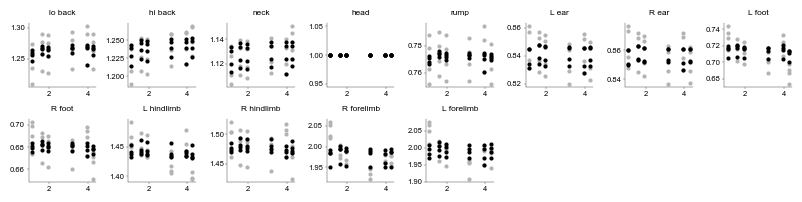

In [27]:
rescale = True
group_order = [ref_age] + tgt_ages


sessions = dataset.sessions
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)
bls_canon = {s: _bone_lengths(canonicalized.get_session(s), arms).mean(axis = 0) for s in dataset_feats.sessions}
bls_raw = {s: _bone_lengths(raw.get_session(s), arms).mean(axis = 0) for s in dataset_feats.sessions}

age_groups = {a: [s for s in dataset_feats.sessions if re.search(r"(\d+)bod", s).group(1) == a] for a in [ref_age] + tgt_ages}
age_order = [ref_age] + tgt_ages


cov = lambda x, y: (x * y).mean(axis=-1) - x.mean(axis=-1) * y.mean(axis=-1)
coef = lambda a, b: cov(a, b) / cov(a, a)
coefs_raw = np.zeros([len(bone_names)] * 2)
coefs_canon = np.zeros([len(bone_names)] * 2)
 

fig, axes, ax_grid = viz.util.flat_grid(len(bone_ix_order), 8, (1, 1), sharex=False, sharey=False)

for (r, r_ix), (c, (c_ix, ax)) in iit.product(enumerate(bone_ix_order), enumerate(zip(bone_ix_order, axes))):
    # if r == c:
        # continue
    logage = np.log([int(a) for a in age_order])

    rto_canon = np.array([
        np.array([bls_canon[s][c_ix] for s in age_groups[a]]) / np.array([bls_canon[s][head_ix] for s in age_groups[a]])
        for a in age_order
    ])
    # coefs_canon[r, c] = [coef(logage, rto_canon[i]) for i in range(rto_canon.shape[1])]

    rto_raw = np.array([
        np.array([bls_raw[s][c_ix] for s in age_groups[a]]) / np.array([bls_raw[s][head_ix] for s in age_groups[a]])
        for a in age_order
    ])
    # coefs_raw[r, c] = [coef(logage, rto_raw[i]) for i in range(rto_raw.shape[1])]
    if r_ix == 0:
        ax.plot(logage, rto_raw, 'o', ms = 3, mew = 0, color = '.7')
        ax.plot(logage, rto_canon, 'o', ms = 3,  mew = 0, color = 'k')
        ax.set_title(short_names[c_ix])
    


# viz.util.legend(ax, loc = 'upper left', fontsize = 6, frameon = False)
# ax.set_yticks([0, 3e-2, 6e-2])
plotter.finalize(fig, None)

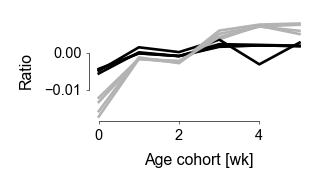

In [107]:
head_ix = [bone_names.index(short_names.inverse[b]) for b in ['head', 'neck', 'rump']]
back_ix = [bone_names.index(short_names.inverse[b]) for b in ['lo back', 'hi back']]


rescale = True
_align_meta= {'scale': np.array(align_meta['scale'])}
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats, merged_params, None, rescale=rescale, scale_to=scale_to, _align_meta=_align_meta)
bls_canon = {s: np.array(_bone_lengths(canonicalized.get_session(s), arms).mean(axis = 0)) for s in dataset_feats.sessions}
bls_raw = {s: np.array(_bone_lengths(raw.get_session(s), arms).mean(axis = 0)) for s in dataset_feats.sessions}

rto_canon = {s: (bls_canon[s][back_ix].mean(axis = 0)) / bls_canon[s][head_ix].mean(axis = 0) for s in dataset_feats.sessions}
rto_raw = {s: (bls_raw[s][back_ix].mean(axis = 0)) / bls_raw[s][head_ix].mean(axis = 0) for s in dataset_feats.sessions}
ages = [ref_age] + tgt_ages
age_groups = {a: [s for s in dataset_feats.sessions if re.search(r"(\d+)bod", s).group(1) == a] for a in ages}
rto_canon = [np.array([rto_canon[s] for s in age_groups[a]]) for a in ages]
rto_raw = [np.array([rto_raw[s] for s in age_groups[a]]) for a in ages]
rto_canon = [r - np.mean(rto_canon, axis = 0) for r in rto_canon]
rto_raw = [r - np.mean(rto_raw, axis = 0) for r in rto_raw]


fig, ax = plt.subplots(figsize = (1.5, 0.7), dpi=190)
for i in range(4):
    ax.plot([r[i] for r in rto_canon], '-', lw = 1, color = 'k')
    ax.plot([r[i] for r in rto_raw], '-', lw = 1, color = '.7')
ax.set_ylabel('Ratio')
ax.set_xlabel('Age cohort [wk]')
sns.despine(ax = ax, trim = True)


### E. Framewise classification accuracy

In [246]:
# Canonicalized and naive-scale-aligned
sessions = dataset.sessions
canonicalized, raw, _ = canonicalized_and_raw(dataset_feats_full, merged_params, None, rescale=False)

feats_raw = calculate_feat_scaled_kp_normed({
    s: raw.get_session(s)
    for s in sessions
}, arms, subsample=50)
feats_canon = calculate_feat_scaled_kp_normed({
    s: canonicalized.get_session(s)
    for s in sessions
}, arms, subsample=50)

groups = set(re.search(r"(\d+)bod", s).group(1) for s in sessions)
groups = {k: [s for s in sessions if re.search(r"(\d+)bod", s).group(1) == k] for k in groups}
indivs = {i: [s for s in sessions if re.search(r"_m(\d+)", s).group(1) == i] for i in "01"}

c_scores = calc_indiv_filtered_scores(feats_canon, groups, ref_age, tgt_ages, indivs, n_iter = 4)
r_scores = calc_indiv_filtered_scores(feats_raw, groups, ref_age, tgt_ages, indivs, n_iter = 4)

100%|██████████| 21/21 [00:28<00:00,  1.36s/it]


/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of f

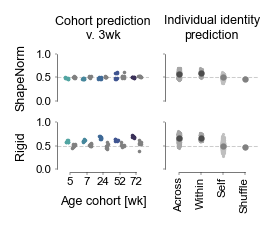

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f4.1_learns-morph/e-linear-classif.pdf')

In [247]:
fig, ax = plt.subplots(2, 2, figsize=(1.8, 1.5), dpi = 150)

classif_strip_points(ax[0, 0], tgt_ages, c_scores[0], [sim_pal[a] for a in tgt_ages], -0.2)
classif_strip_points(ax[0, 0], tgt_ages, c_scores[1], ['.5'] * len(tgt_ages), 0.2)
allway_scores = [c_scores[2][i] for i in [0, 2, 1, 3]]
classif_strip(ax[0, 1], range(4), allway_scores, ['.3', '.3', '.5', '.5'], 0)

classif_strip_points(ax[1, 0], tgt_ages, r_scores[0], [sim_pal[a] for a in tgt_ages], -0.2)
classif_strip_points(ax[1, 0], tgt_ages, r_scores[1], ['.5'] * len(tgt_ages), 0.2)
allway_scores = [r_scores[2][i] for i in [0, 2, 1, 3]]
classif_strip(ax[1, 1], range(4), allway_scores, ['.3', '.3', '.5', '.5'], 0)


ax[1, 0].set_xticks(np.arange(len(tgt_ages)))
ax[1, 0].set_xticklabels(tgt_ages)
ax[0, 0].set_xlim(-0.8, len(tgt_ages) - 1 + 0.8)
ax[1, 0].set_xlim(-0.8, len(tgt_ages) - 1 + 0.8)
ax[1, 1].set_xticks(np.arange(4))
ax[1, 1].set_xticklabels(["Across", "Within", "Self", "Shuffle"], rotation = 90, fontsize = 5.5)
ax[0, 1].set_xlim(-0.6, 3 + 0.6)
ax[1, 1].set_xlim(-0.6, 3 + 0.6)

for a in ax.ravel():
    a.set_ylim(-0.05, 1.05)
    
    a.axhline(0.5, ls = '--', lw = 0.5, color = '.8', zorder = -3)
for a in ax.ravel():
    sns.despine(ax = a, trim = True)
for a in ax[0]:
    a.set_xticks([])
    a.spines['bottom'].set_visible(False)
for a in ax[:, 1]:
    a.set_yticklabels([""] * 3)



ax[0, 0].set_ylabel("ShapeNorm")
ax[1, 0].set_ylabel("Rigid")
ax[1, 0].set_xlabel("Age cohort [wk]")
ax[0, 0].set_title(f"Cohort prediction\nv. {ref_age}wk")
ax[0, 1].set_title("Individual identity\nprediction")



plotter.finalize(fig, "e-linear-classif", despine = False,)

/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/kaifox/bin/miniconda3/envs/shapenorm/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of f

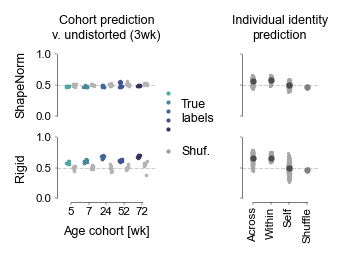

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f4.1_learns-morph/e-linear-classif-legend.pdf')

In [243]:
fig, ax = plt.subplots(2, 3, figsize=(2.2, 1.7), dpi = 150, width_ratios=[1.3, 0.7, 1])
for a in ax[:, 1]:
    a.set_visible(False)
ax = ax[:, [0, 2]]

classif_strip_points(ax[0, 0], tgt_ages, c_scores[0], [sim_pal[a] for a in tgt_ages], -0.2)
classif_strip_points(ax[0, 0], tgt_ages, c_scores[1], ['.7'] * len(tgt_ages), 0.2)
allway_scores = [c_scores[2][i] for i in [0, 2, 1, 3]]
classif_strip(ax[0, 1], range(4), allway_scores, ['.3', '.3', '.3', '.5'], 0)

classif_strip_points(ax[1, 0], tgt_ages, r_scores[0], [sim_pal[a] for a in tgt_ages], -0.2)
classif_strip_points(ax[1, 0], tgt_ages, r_scores[1], ['.7'] * len(tgt_ages), 0.2)
allway_scores = [r_scores[2][i] for i in [0, 2, 1, 3]]
classif_strip(ax[1, 1], range(4), allway_scores, ['.3', '.3', '.3', '.5'], 0)

handles = [ax[0, 0].plot([np.nan], [np.nan], 'o', ms = 2, mew = 0, color = sim_pal[a], label = " ")[0] for a in tgt_ages]
handles_shuf = ax[0, 0].plot([np.nan], [np.nan], 'o', ms = 2, mew = 0, color = '.6', label = " ")

ax[1, 0].set_xticks(np.arange(len(tgt_ages)))
ax[1, 0].set_xticklabels(tgt_ages)
ax[0, 0].set_xlim(-0.8, len(tgt_ages) - 1 + 0.8)
ax[1, 0].set_xlim(-0.8, len(tgt_ages) - 1 + 0.8)
ax[1, 1].set_xticks(np.arange(4))
ax[1, 1].set_xticklabels(["Across", "Within", "Self", "Shuffle"], rotation = 90, fontsize = 5.5)
ax[0, 1].set_xlim(-0.6, 3 + 0.6)
ax[1, 1].set_xlim(-0.6, 3 + 0.6)

for a in ax.ravel():
    a.set_ylim(-0.05, 1.05)
    a.axhline(0.5, ls = '--', lw = 0.5, color = '.8', zorder = -3)
for a in ax.ravel():
    sns.despine(ax = a, trim = True)
for a in ax[0]:
    a.set_xticks([])
    a.spines['bottom'].set_visible(False)
for a in ax[:, 1]:
    a.set_yticklabels([""] * 3)



ax[0, 0].set_ylabel("ShapeNorm")
ax[1, 0].set_ylabel("Rigid")
ax[1, 0].set_xlabel("Age cohort [wk]")
ax[0, 0].set_title(f"Cohort prediction\nv. undistorted ({ref_age}wk)")
ax[0, 1].set_title("Individual identity\nprediction")
fig.tight_layout()

leg = viz.util.legend(ax[0, 0], (handles, " " * len(tgt_ages)), loc='center left', bbox_to_anchor = (0.9, 0.1), labelspacing=-.1)
ax[0, 0].text(1.25, 0.1, "True\nlabels", ha='left', va='center', transform=ax[0, 0].transAxes)
viz.util.legend(ax[0, 0], (handles_shuf, [" "]), loc='center left', bbox_to_anchor = (0.9, -0.5), labelspacing=0.)
ax[0, 0].text(1.25, -0.5, "Shuf.", ha='left', va='center', transform=ax[0, 0].transAxes)
ax[0, 0].add_artist(leg)


plotter.finalize(fig, "e-linear-classif-legend", despine = False, tight = False)

### F. Usage difference across session halves

#### Bar plot for example session

weights array: (2, 4)


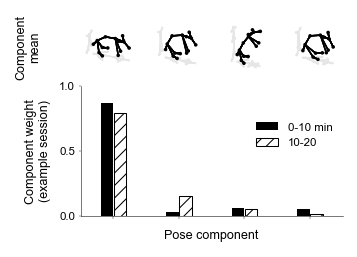

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f4.1_learns-morph/f-mixture-weights.pdf')

In [16]:
ex_weights = np.array([
    params.pose.subj_weights[scan_dataset.session_id(f"{ref_age}wk_{ref_age}bod_m0.{part}")] for part in '01'
])
print("weights array:", ex_weights.shape)
comp_order = np.argsort(ex_weights.mean(axis = 0))[::-1]
selected_comps = [0, 1, 2, 3]
inflated_comps = features.inflate(params.pose.means, cfg["features"])
ordered_avg = ex_weights[:, comp_order]

# 3d plotting with shadow
kws = lambda c, ps, ls: dict(
    armature = arms,
    elev = 30, 
    rot = -70,
    colors = np.array([c] * arms.n_kpts),
    point_size = ps,
    line_size = ls,
    boundary=False
)
dropz = lambda x, z: np.concatenate([x[:, :2], np.broadcast_to(x[:, 2].min() + z, x.shape[:-1] + (1,))], axis = -1) 
dropy = lambda x, y: np.concatenate([x[:, :1], np.broadcast_to(x[:, 1].max() + y, x.shape[:-1] + (1,)), x[:, 2:]], axis = -1)
dropx = lambda x, xx: np.concatenate([np.broadcast_to(x[:, 0].min() + xx, x.shape[:-1] + (1,)), x[:, 1:]], axis = -1)
plotdrop = lambda f, a, c, sm=1, lsm=1, shad=True, dropax=None, shadx=True, shady=True, shadz=True: [
    plot_mouse_3d(f, a, **kws(c, sm * 15, 1.5 * lsm))
    ] + [
    dropax := dropax if dropax is not None else a,
    ] + ([
    plot_mouse_3d(dropz(f, -7), dropax, **kws('.9', sm * 7, 1 * lsm)) if shadz else None,
    plot_mouse_3d(dropy(f, 10), dropax, **kws('.9', sm * 7, 1 * lsm)) if shady else None,
    plot_mouse_3d(dropx(f, -7), dropax, **kws('.9', sm * 7, 1 * lsm)) if shadx else None,
] if shad else [])

# ---- component means
n_select = len(selected_comps)
fig = plt.figure(figsize = (0.5 * (n_select) + 0.3, 1.8), dpi = 150)
gs_top_row = plt.GridSpec(2, n_select, height_ratios=[2, 2.5], hspace=0)
gs_main = plt.GridSpec(2, 1, height_ratios=[2, 3])

top_row = []
for i in range(n_select):
    ax = fig.add_subplot(gs_top_row[0, i], projection='3d')
    top_row.append(ax)
    if i > 0:
        ax.sharey(top_row[0])
    frame = inflated_comps[comp_order[selected_comps[i]]]
    plotdrop(frame, ax, 'k', sm = 0.2, lsm = 0.4, shady=False)

# ---- Total component usages

bar_width = 0.19
ax = fig.add_subplot(gs_main[1])
for i, (usage, f, h, l) in enumerate(zip(ordered_avg, [True, False], [None, '////'], ["0-10 min", "10-20"])):
    ax.bar(
        np.arange(params.pose.n_components) + 1. * viz.util.get_offsets(2, i),
        usage,
        width = bar_width,
        color = 'k',
        fill = f,
        hatch = h, 
        bottom=0,
        lw = 0.5
    )

    # labels
    ax.bar([0], [np.nan], 
        color = 'k',
        fill = f,
        hatch = h,
        label = l,
        lw = 0.5)

ax.set_xticks(np.arange(params.pose.n_components))
ax.set_xticklabels([""] * params.pose.n_components)
ax.set_xlim(-0.5, params.pose.n_components - 1 + 0.5)
# ax.set_ylim(1e-3, 1)
# ax.set_ylabel("Usage time [frac]\n(example session)")
# ax.set_yscale('log')
ax.set_ylabel("Component weight\n(example session)")
ax.set_yticks([0, 0.5, 1.])
ax.set_xlabel("Pose component")
sns.despine(ax = ax)

plt.tight_layout()

leg = viz.util.legend(ax, viz.util.unique_handles(ax), loc = 'upper right', bbox_to_anchor = (1, 0.8))
top_row[0].text2D(-0.95, 0.5, 'Component\nmean', ha='center', va='center', rotation='vertical', fontsize=6, transform=top_row[0].transAxes)

for leg in [tgt_leg, ref_leg]:
    leg.get_title().set_fontsize(6)
    leg.get_title().set_horizontalalignment('left')
plotter.finalize(fig, 'f-mixture-weights', despine = False, tight=False)

#### Example session behavior by session half

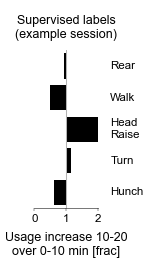

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f4.1_learns-morph/f-explain-bhv-diffs.pdf')

In [19]:
session_half_splits = {s: np.diff(scan_dataset_full.get_slice(f"{s}.0"))[0] for s in dataset.sessions}
ex_session = f"{ref_age}wk_{ref_age}bod_m0"
ex_session_source = f"{ref_age}wk_m0"


bar_width = 0.8
fig, ax = plt.subplots(1, 1, figsize = (1., 1.8), dpi=150)
for i, k in enumerate(bhv_order):
    part0 = bhv_masks[k][ex_session_source][:session_half_splits[ex_session]]
    part1 = bhv_masks[k][ex_session_source][session_half_splits[ex_session]:]
    fc = part1.mean() / part0.mean() 
    ax.barh(
        [len(bhv_order) - i - 1],
        [fc - 1 if fc > 1 else 1 - fc],
        height = bar_width,
        color = 'k',
        left=[1 if fc > 1 else fc],
        lw = 0.
    )
    ax.text(
        2.4, len(bhv_order) - i - 1, bhv_names[k],
        ha = 'left', va = 'center', fontsize = 5.5
    )
ax.set_ylim(-0.5, len(bhv_order) - 0.5)
ax.set_xlim(0, 2)
ax.set_xticks([0, 1, 2])
ax.set_yticks([])
ax.spines['left'].set_visible(False)

ax.axvline(1, color = '.7', lw = 0.5)
ax.set_xlabel("Usage increase 10-20\nover 0-10 min [frac]")
ax.set_title("Supervised labels\n(example session)")

plotter.finalize(fig, 'f-explain-bhv-diffs', despine=False)


#### Quantification

weights array: (4, 6, 2, 4)


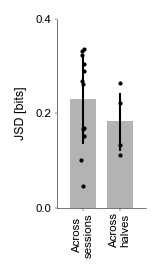

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f4.1_learns-morph/f-compare-weights.pdf')

In [119]:
ex_weights = np.array([[
    [params.pose.subj_weights[scan_dataset.session_id(f"{ref_age}wk_{a}bod_m{animal_id}.{part}")] for part in '01']
    for a in [ref_age] + tgt_ages] for animal_id in animal_ids
])
print("weights array:", ex_weights.shape)



# ---- component means

fig, axes = plt.subplots(1, 1, figsize = (1.05, 1.8), dpi = 150)

# ---- Component usages vs reference

ax = axes


across_animal = [jensenshannon(ex_weights[j, 0, i], ex_weights[k, 0, i], base=2) for j, k in iit.combinations(animal_ids, 2) for i in range(2)]
viz.util.grouped_stripplot(
    [np.array(across_animal)],
    x = [0],
    colors = mpl_col.to_rgba('k'),
    points_kw={'ms': 1},
    errorbar_kw=dict(ms=0),
)
ax.bar([0], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(across_animal), 0),)
to_ref = [jensenshannon(ex_weights[j, 0, 1], ex_weights[j, 0, 0], base=2) for j in animal_ids]

viz.util.grouped_stripplot(
    [np.array(to_ref).ravel()],
    x = [1],
    colors = 'k',
    points_kw={'ms': 1},
    jitter=0.0,
    errorbar=False,
    error=lambda x: viz.util.ci(x, np.nanmean, 0.95),
)    
viz.util.grouped_stripplot(
    [np.array(to_ref).ravel()],
    x = [1],
    colors = mpl_col.to_rgba('k'),
    points=False,
    errorbar_kw=dict(ms=0),
    error=lambda x: viz.util.ci(x, np.nanmean, 0.95),
)
ax.bar([1], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(to_ref), 0),)
    
    
ax.set_ylabel("JSD [bits]")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Across\nsessions", "Across\nhalves"], rotation=90)
ax.set_xlim(-0.7, 1.7)
ax.set_yticks([0, 0.2, 0.4])

plotter.finalize(fig, 'f-compare-weights', despine = False,)

### G. Dependence of learned morph on behavior model

##### Display example frames

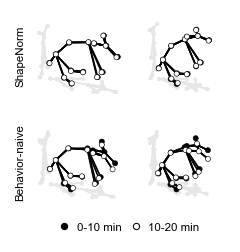

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f4.1_learns-morph/g-naive-equivalent-poses-anchor.pdf')

In [405]:
scan_align_meta = {'scale': np.array([-1. for _ in scan_dataset.sessions])}
for src_sess, splits in split_meta[1].items():
    for s in splits:
        scan_align_meta['scale'][scan_dataset.session_id(s)] = align_meta['scale'][dataset.session_id(src_sess)]

n_display=2

naive_anchors = naive_model_anchors(
    naive_canonicalized,
    naive_params,
    cfg,
)

shapenorm_anchors = anchor_keypoints(
    params.morph,
    {},
    magnitudes=anchor_magnitudes(scan_dataset, params.morph, q = 0.1),
    config=cfg,
    session_meta=scan_dataset.session_meta,
)


kws = lambda fc, ec, ps, ls, label=None: dict(
    armature = arms,
    elev = 30, 
    rot = -70,
    colors = np.array([fc] * arms.n_kpts),
    line_colors = np.array([ec] * arms.n_kpts),
    point_size = ps,
    line_size = ls,
    label=label,
    point_kws = {'edgecolor': np.array([ec]*arms.n_kpts), 'linewidths': np.array([ls / 2]*arms.n_kpts)},
    boundary=False,
)
dropz = lambda x, z: np.concatenate([x[:, :2], np.broadcast_to(x[:, 2].min() + z, x.shape[:-1] + (1,))], axis = -1) 
dropy = lambda x, y: np.concatenate([x[:, :1], np.broadcast_to(x[:, 1].max() + y, x.shape[:-1] + (1,)), x[:, 2:]], axis = -1)
dropx = lambda x, xx: np.concatenate([np.broadcast_to(x[:, 0].min() + xx, x.shape[:-1] + (1,)), x[:, 1:]], axis = -1)
plotdrop = lambda f, a, fc, ec, sm=1, lsm=1, shad=True, dropax=None, label=None, shadx=True, shady=True, shadz=True: [
    plot_mouse_3d(f, a, **kws(fc, ec, sm * 15, 1.5 * lsm, label))
    ] + [
    dropax := dropax if dropax is not None else a,
    ] + ([
    plot_mouse_3d(dropz(f, -5), dropax, **kws('.9', '.9', sm * 7, 1 * lsm)) if shadz else None,
    plot_mouse_3d(dropy(f, 15), dropax, **kws('.9', '.9', sm * 7, 1 * lsm)) if shady else None,
    plot_mouse_3d(dropx(f, -5), dropax, **kws('.9', '.9', sm * 7, 1 * lsm)) if shadx else None,
] if shad else [])

gs = plt.GridSpec(2, n_display, height_ratios=[1, 1], wspace=0)
fig = plt.figure(figsize=(1.5, 1.5), dpi=150)
row0_shad = np.array([fig.add_subplot(gs[0, i], projection='3d') for i in range(n_display)])
row1_shad = np.array([fig.add_subplot(gs[1, i], projection='3d') for i in range(n_display)])
row0_back = np.array([fig.add_subplot(gs[0, i], projection='3d') for i in range(n_display)])
row1_back = np.array([fig.add_subplot(gs[1, i], projection='3d') for i in range(n_display)])
row0_frnt = np.array([fig.add_subplot(gs[0, i], projection='3d') for i in range(n_display)])
row1_frnt = np.array([fig.add_subplot(gs[1, i], projection='3d') for i in range(n_display)])

ex_sess = f'{ref_age}wk_{ref_age}bod_m1'
ref_body = scan_dataset.session_body_id(f'{ex_sess}.0')
tgt_body = scan_dataset.session_body_id(f'{ex_sess}.1')
for i in range(n_display):
    for tgt in [row0_shad, row0_frnt, row1_shad, row1_back, row1_frnt]:
        tgt[i].sharex(row0_back[i])
        tgt[i].sharey(row0_back[i])
        tgt[i].sharez(row0_back[i])

for i in range(n_display):
    plotdrop(shapenorm_anchors[ref_body, i], row0_back[i], 'k', 'k', 0.4, 0.4, True, dropax=row0_shad[i], shady=False)
    plotdrop(shapenorm_anchors[tgt_body, i], row0_frnt[i], 'w', 'k', 0.4, 0.4, True, dropax=row0_shad[i], shady=False)

    plotdrop(naive_anchors[ex_sess][0, i], row1_back[i], 'k', 'k', 0.4, 0.4, True, dropax=row1_shad[i], shady=False)
    plotdrop(naive_anchors[ex_sess][1, i], row1_frnt[i], 'w', 'k', 0.4, 0.4, True, dropax=row1_shad[i], shady=False)

fig.tight_layout()
row0_back[0].text2D(-0.15, 0.55, f"ShapeNorm", ha = 'center', va = 'center', rotation=90, size=5.5, transform=row0_back[0].transAxes)
row1_back[0].text2D(-0.15, 0.55, f"Behavior-naive", ha = 'center', va = 'center', rotation=90, size=5.5, transform=row1_back[0].transAxes)

row1_frnt[0].plot([np.nan], [np.nan], [np.nan], 'o', mfc='k', mec='k', mew=0.5, ms = 3, label='0-10 min')
row1_frnt[0].plot([np.nan], [np.nan], [np.nan], 'o', mfc='w', mec='k', mew=0.5, ms = 3, label='10-20 min')
viz.util.legend(row1_frnt[0], loc = 'upper center', bbox_to_anchor = (1, 0.), ncol=2, columnspacing=0.2, handletextpad=0.1)

plotter.finalize(fig, 'g-naive-equivalent-poses-anchor', tight=False)

##### Quantify: mean keypoint distance in generated poses

In [45]:
# --- map sessions onto paired body
part0bod_naive = {s: features.inflate(naive_canonicalized[s], cfg['features']) for s in scan_dataset.sessions}
part1bod_naive = {}
part0bod_aware = {}
part1bod_aware = {}
partibod_aware = [part0bod_aware, part1bod_aware]

aware_canon, _, _ = canonicalized_and_raw(scan_dataset, params.morph, None, rescale=False)


for s in scan_dataset.sessions:
    src_s = [k for k, v in split_meta[1].items() if s in v][0]

    # Apply naive part0->part1 body mapping for canonicalized data from `s`
    dset = single_session_dataset(
        naive_canonicalized[s],
        "body0",
        "s0",
        SessionMetadata(
            session_ids={"s0": 0},
            body_ids={"body0": 0, "body1": 1},
            session_bodies={"s0": 0},
        ),
    )
    poses = model_util.apply_bodies(
        model.morph, naive_params[src_s], dset, {"s0": "body1"}
    ).get_session("s0")
    part1bod_naive[s] = features.inflate(poses, cfg['features'])

    # Apply informed ref->part{i} body mapping for canonicalized data from `s`
    for i in range(2):
        dset = single_session_dataset(
            features.reduce_to_features(aware_canon.get_session(s), cfg['features']),
            scan_dataset.session_body_name(scan_dataset.ref_session),
            s,
            scan_dataset.session_meta,
        )
        poses = model_util.apply_bodies(
            model.morph, params.morph, dset, {s: scan_dataset.session_body_name(f"{src_s}.{i}")}
        ).get_session(s)
        partibod_aware[i][s] = features.inflate(poses, cfg['features'])

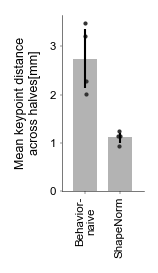

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f4.1_learns-morph/g-compare-errs.pdf')

In [105]:
# distances in above keypoints
sessions = [s for s in dataset.sessions if re.search(r"(\d+)bod", s).group(1) == ref_age]
errs = {
    k: [
        np.concatenate([model_util.reconst_errs(part0kp[f"{s}.{part}"], part1kp[f"{s}.{part}"], average=False) for part in "01"]).mean()
        for s in sessions
    ]
    for k, part0kp, part1kp in [
        (f"naive", part0bod_naive, part1bod_naive),
        (f"aware", part0bod_aware, part1bod_aware),
    ]  
}


fig, ax = plt.subplots(1, 1, figsize=(1.1, 1.8), dpi=150)

viz.util.grouped_stripplot(
    [np.array(errs['naive'])],
    x = [0],
    colors = mpl_col.to_rgba('k'),
    points_kw={'ms': 1},
    lighten_points=0.2,
    errorbar_kw=dict(ms=0),
)
ax.bar([0], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(errs['naive']), 0),)

viz.util.grouped_stripplot(
    [np.array(errs['aware'])],
    x=[1],
    colors=mpl_col.to_rgba("k"),
    errorbar_kw=dict(ms=0),
    points_kw={'ms': 1},
    lighten_points=0.2,
    error=lambda x: viz.util.ci(x, np.nanmean, 0.95),
)
ax.bar([1], color=".7", width=0.7, **viz.util.stem_bar(np.mean(errs['aware']), 0),)


ax.set_ylabel("Mean keypoint distance\nacross halves[mm]")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Behavior-\nnaive", "ShapeNorm"], rotation=90)
ax.set_xlim(-0.7, 1.7)

plotter.finalize(fig, "g-compare-errs", despine=False)

### H. Learns behavior and morph simultaneously

#### Bar plot of component weights for example session

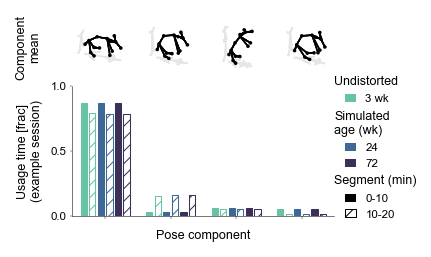

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f4.1_learns-morph/h-mixture-weights.pdf')

In [107]:
ex_weights = np.array([
    [params.pose.subj_weights[scan_dataset.session_id(f"{ref_age}wk_{a}bod_m0.{part}")] for part in '01']
    for a in [ref_age] + tgt_ages
])
comp_order = np.argsort(np.mean(ex_weights, axis = 0).mean(axis = 0))[::-1]
selected_comps = [0, 1, 2, 3]
inflated_comps = features.inflate(params.pose.means, cfg["features"])
ordered_weights = ex_weights[:, :, comp_order]

# 3d plotting with shadow
kws = lambda c, ps, ls: dict(
    armature = arms,
    elev = 30, 
    rot = -70,
    colors = np.array([c] * arms.n_kpts),
    point_size = ps,
    line_size = ls,
    boundary=False
)
dropz = lambda x, z: np.concatenate([x[:, :2], np.broadcast_to(x[:, 2].min() + z, x.shape[:-1] + (1,))], axis = -1) 
dropy = lambda x, y: np.concatenate([x[:, :1], np.broadcast_to(x[:, 1].max() + y, x.shape[:-1] + (1,)), x[:, 2:]], axis = -1)
dropx = lambda x, xx: np.concatenate([np.broadcast_to(x[:, 0].min() + xx, x.shape[:-1] + (1,)), x[:, 1:]], axis = -1)
plotdrop = lambda f, a, c, sm=1, lsm=1, shad=True, dropax=None, shadx=True, shady=True, shadz=True: [
    plot_mouse_3d(f, a, **kws(c, sm * 15, 1.5 * lsm))
    ] + [
    dropax := dropax if dropax is not None else a,
    ] + ([
    plot_mouse_3d(dropz(f, -7), dropax, **kws('.9', sm * 7, 1 * lsm)) if shadz else None,
    plot_mouse_3d(dropy(f, 10), dropax, **kws('.9', sm * 7, 1 * lsm)) if shady else None,
    plot_mouse_3d(dropx(f, -7), dropax, **kws('.9', sm * 7, 1 * lsm)) if shadx else None,
] if shad else [])

# ---- component means
n_select = len(selected_comps)
fig = plt.figure(figsize = (0.5 * (n_select) + 0.3, 1.8), dpi = 150)
gs_top_row = plt.GridSpec(2, n_select, height_ratios=[2, 2.5], hspace=0)
gs_main = plt.GridSpec(2, 1, height_ratios=[2, 3])

top_row = []
for i in range(n_select):
    ax = fig.add_subplot(gs_top_row[0, i], projection='3d')
    top_row.append(ax)
    if i > 0:
        ax.sharey(top_row[0])
    frame = inflated_comps[comp_order[selected_comps[i]]]
    plotdrop(frame, ax, 'k', sm = 0.2, lsm = 0.4, shady=False)

# ---- Component usages by age/half

bar_width = 0.095
ax = fig.add_subplot(gs_main[1])
disp_ages = [ref_age] + ["24", "72"]
for i, (usage, a) in enumerate(zip(ordered_weights, disp_ages)):
    for j, (part, f, h) in enumerate(zip("01", [True, False], [None, "////"])):
        x = j + i * 2
        ax.bar(
            np.arange(params.pose.n_components) + 1.3 * viz.util.get_offsets(2*len(disp_ages), x),
            usage[j],
            width = bar_width,
            color = sim_pal[a],
            edgecolor = sim_pal[a],
            bottom=0,
            lw=0.5,
            hatch=h,
            fill = f,
        )

    # labels
    ax.bar([0], [np.nan], color = sim_pal[a], label = f"{a}")

part_lh = [
    ("0-10", ax.bar([0], [np.nan], color = 'k', lw = 0.5, label = f"0-10"))[::-1],
    ("10-20", ax.bar([0], [np.nan], color = 'k', lw = 0.5, fill=False, hatch = '////', label = f"10-20"))[::-1],
]

ax.set_xticks(np.arange(params.pose.n_components))
ax.set_xticklabels([""] * params.pose.n_components)
ax.set_xlim(-0.5, params.pose.n_components - 1 + 0.5)
# ax.set_ylim(1e-2, 1)
ax.set_ylabel("Usage time [frac]\n(example session)")
ax.set_yticks([0, 0.5, 1.])
# ax.set_yscale('log')
ax.set_xlabel("Pose component")
sns.despine(ax = ax)

plt.tight_layout()
tgt_lh = [(h, l) for h, l in zip(*ax.get_legend_handles_labels()) if l in tgt_ages]
ref_lh = [(h, f"{l} wk") for h, l in zip(*ax.get_legend_handles_labels()) if l == ref_age]
ax.text(1, 0.99, "Undistorted", ha='left', va='bottom', transform=ax.transAxes)
ax.text(1, 0.61, "Simulated\nage (wk)", ha='left', va='bottom', transform=ax.transAxes)
ax.text(1, 0.22, "Segment (min)", ha='left', va='bottom', transform=ax.transAxes)
tgt_leg = viz.util.legend(ax, zip(*tgt_lh), loc = 'upper left', bbox_to_anchor = (1., 0.64), handlelength=1.)#, title="Simulated\nage (wk)")
ref_leg = viz.util.legend(ax, zip(*ref_lh), loc = 'upper left', bbox_to_anchor = (1., 1.02), handlelength=1.)#, title="Undistorted")
prt_leg = viz.util.legend(ax, zip(*part_lh), loc = 'upper left', bbox_to_anchor = (1., 0.25), handlelength=1.)#, title="Segment")
ax.add_artist(tgt_leg)
ax.add_artist(ref_leg)
top_row[0].text2D(-0.8, 0.5, 'Component\nmean', ha='center', va='center', rotation='vertical', fontsize=6, transform=top_row[0].transAxes)

for leg in [tgt_leg, ref_leg, prt_leg]:
    leg.get_title().set_fontsize(6)
    leg.get_title().set_horizontalalignment('left')
plotter.finalize(fig, 'h-mixture-weights', despine = False, tight=False)

#### Quantify weights across distortion and segment

weights array: (4, 6, 2, 4)


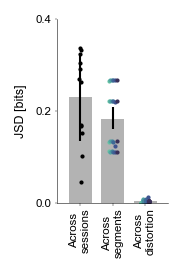

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f4.1_learns-morph/h-compare-weights.pdf')

In [117]:
ex_weights = np.array([[
    [params.pose.subj_weights[scan_dataset.session_id(f"{ref_age}wk_{a}bod_m{animal_id}.{part}")] for part in '01']
    for a in [ref_age] + tgt_ages] for animal_id in animal_ids
])
print("weights array:", ex_weights.shape)



# ---- component means

fig, axes = plt.subplots(1, 1, figsize = (1.2, 1.8), dpi = 150)

# ---- Component usages vs reference

ax = axes


# --- across session
across_animal = [jensenshannon(ex_weights[j, 0, i], ex_weights[k, 0, i], base=2) for j, k in iit.combinations(animal_ids, 2) for i in range(2)]
viz.util.grouped_stripplot(
    [np.array(across_animal)],
    x = [0],
    colors = mpl_col.to_rgba('k'),
    points_kw={'ms': 1},
    errorbar_kw=dict(ms=0),
)
ax.bar([0], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(across_animal), 0),)

# --- across segment
to_ref = [[jensenshannon(ex_weights[j, i, 1], ex_weights[j, i, 0], base=2) for j in animal_ids] for i, a in enumerate([ref_age] + tgt_ages)]
for i, a in enumerate([ref_age] + tgt_ages):
    viz.util.grouped_stripplot(
        [np.array(to_ref[i]).ravel()],
        x = [1 + 0.5 * viz.util.get_offsets(len(tgt_ages)+1, i)],
        colors = sim_pal[a],
        points_kw={'ms': 1},
        jitter=0.0,
        errorbar=False,
        error=lambda x: viz.util.ci(x, np.nanmean, 0.95),
    )    
viz.util.grouped_stripplot(
    [np.array(to_ref).ravel()],
    x = [1],
    colors = mpl_col.to_rgba('k'),
    points=False,
    errorbar_kw=dict(ms=0),
    error=lambda x: viz.util.ci(x, np.nanmean, 0.95),
)
ax.bar([1], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(to_ref), 0),)

# --- across distortion
to_ref = [[jensenshannon(ex_weights[j, i, k], ex_weights[j, 0, k], base=2) for j in animal_ids for k in range(2)] for i, a in enumerate([ref_age] + tgt_ages)]
for i, (a, refdata) in enumerate(zip([ref_age] + tgt_ages, to_ref)):
    viz.util.grouped_stripplot(
        [np.array(refdata).ravel()],
        x = [2 + 0.5 * viz.util.get_offsets(len(tgt_ages)+1, i)],
        colors = sim_pal[a],
        points_kw={'ms': 1},
        jitter=0.0,
        errorbar=False,
        error=lambda x: viz.util.ci(x, np.nanmean, 0.95),
    )    
viz.util.grouped_stripplot(
    [np.array(to_ref).ravel()],
    x = [2],
    colors = mpl_col.to_rgba('k'),
    points=False,
    errorbar_kw=dict(ms=0),
    error=lambda x: viz.util.ci(x, np.nanmean, 0.95),
)
ax.bar([2], color = '.7', width=0.7, **viz.util.stem_bar(np.mean(to_ref), 0),)
    
    
ax.set_ylabel("JSD [bits]")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["Across\nsessions", "Across\nsegments", "Across\ndistortion"], rotation=90)
ax.set_xlim(-0.7, 2.7)
ax.set_yticks([0, 0.2, 0.4])

plotter.finalize(fig, 'h-compare-weights', despine = False,)

#### Morph learned for segments is the same (but not in naive model)
Relies on mapping of keypoints computed in `G > mean keypoint distance in generated poses`

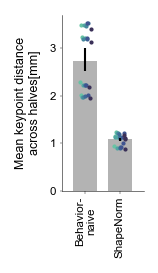

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f4.1_learns-morph/h-compare-errs.pdf')

In [159]:
# distances in above keypoints
errs = {
    k: {
        s: np.concatenate([model_util.reconst_errs(part0kp[f"{s}.{part}"], part1kp[f"{s}.{part}"], average=False) for part in "01"]).mean()
        for s in dataset.sessions
    }
    for k, part0kp, part1kp in [
        (f"naive", part0bod_naive, part1bod_naive),
        (f"aware", part0bod_aware, part1bod_aware),
    ]  
}
age_groups = {a: [s for s in dataset.sessions if re.search(r"(\d+)bod", s).group(1) == a] for a in [ref_age] + tgt_ages}


fig, ax = plt.subplots(1, 1, figsize=(1.1, 1.8), dpi=150)

for i, a in enumerate([ref_age] + tgt_ages):
    viz.util.grouped_stripplot(
        [np.array([errs['naive'][s] for s in age_groups[a]])],
        x = [0.5 * viz.util.get_offsets(len(tgt_ages)+1, i)],
        colors = sim_pal[a],
        points_kw={'ms': 1},
        errorbar=False,
    )
    viz.util.grouped_stripplot(
        [np.array([errs['aware'][s] for s in age_groups[a]])],
        x=[1 + 0.5 * viz.util.get_offsets(len(tgt_ages)+1, i)],
        colors=sim_pal[a],
        points_kw={'ms': 1},
        errorbar=False
    )

viz.util.grouped_stripplot(
    [np.array([*errs['naive'].values()])],
    x = [0],
    colors = mpl_col.to_rgba('k'),
    points=False,
    lighten_points=0.2,
    errorbar_kw=dict(ms=0),
    error=lambda x: viz.util.ci(x, np.nanmean, 0.95),
)
ax.bar([0], color = '.7', width=0.7, **viz.util.stem_bar(np.mean([*errs['naive'].values()]), 0),)

    
viz.util.grouped_stripplot(
    [np.array([*errs['aware'].values()])],
    x = [1],
    colors = mpl_col.to_rgba('k'),
    points=False,
    points_kw={'ms': 1},
    lighten_points=0.2,
    errorbar_kw=dict(ms=0),
    error=lambda x: viz.util.ci(x, np.nanmean, 0.95),
)
ax.bar([1], color=".7", width=0.7, **viz.util.stem_bar(np.mean([*errs['aware'].values()]), 0),)


ax.set_ylabel("Mean keypoint distance\nacross segments [mm]")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Behavior-\nnaive", "ShapeNorm"], rotation=90)
ax.set_xlim(-0.7, 1.7)

plotter.finalize(fig, "h-compare-errs", despine=False)

#### Bone lengths are correctly learned in both segments

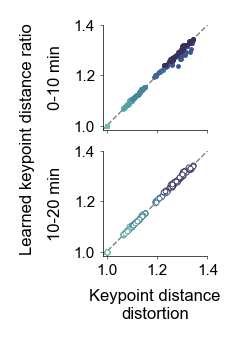

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f4.1_learns-morph/h-anchor-poses-bls-vs-applied.pdf')

In [152]:
rescale = True
sessions = scan_dataset.sessions
pairs = {
    s: re.sub(r"\d+bod", f"{ref_age}bod", s)
    for s in sessions
}

# ---- get rescaled raw data and anchor poses, compute paired bone length ratios
scan_align_meta = {'scale': np.array([-1. for _ in scan_dataset.sessions])}
for src_sess, splits in split_meta[1].items():
    for s in splits:
        scan_align_meta['scale'][scan_dataset.session_id(s)] = align_meta['scale'][dataset.session_id(src_sess)]
canonicalized, raw, _ = canonicalized_and_raw(scan_dataset, params.morph, None, rescale=rescale, scale_to=f"{scale_to}.0", _align_meta=scan_align_meta)
anchors = anchor_keypoints(  # shape (n_session, n_anchor, n_kpt, 3)
    params.morph,
    scan_align_meta if rescale else {},
    magnitudes=anchor_magnitudes(scan_dataset, params.morph, q=0.1),
    config=cfg,
    session_meta=scan_dataset.session_meta,
)

raw_bls = {s: _bone_lengths(raw.get_session(s), arms) for s in sessions}
raw_ratios = {s: raw_bls[s] / raw_bls[pairs[s]] for s in pairs}

anchor_bls = {
    s: _bone_lengths(anchors[scan_dataset.session_id(s)], arms) for s in sessions
}
anchor_ratios = {s: anchor_bls[s] / anchor_bls[pairs[s]] for s in pairs}




# --- plot ratio in raw vs ratio in anchor poses
fig, ax = plt.subplots(2, 1, figsize=(1.2, 1.5), sharex=True, sharey=True, dpi=200)

for s in pairs:
    group = re.search(r"(\d+)bod", s).group(1)
    group_pal = {ref_age: ref_color, **{a: c for a, c in zip(tgt_ages, tgt_colors)}}
    anchor_pal = Colormap('husl')(np.linspace(0, 1, anchors.shape[1]))
    xy = raw_ratios[s].mean(axis = 0), anchor_ratios[s].mean(axis = 0)
    c = group_pal[group]
    part = 0 if re.search(r"\.0$", s) else 1
    if part == 0:
        ax[0].scatter(*xy, color=c, lw = 0.3, s=2)
    else:
        ax[1].scatter(*xy, color=c, lw = 0.3, s=3, fc = 'w')


for a in ax:
    xmin, xmax = a.get_xlim()
    ymin, ymax = a.get_ylim()
    min_, max_ = min(xmin, ymin, 1.), max(xmax, ymax, 1.4)
    a.set_xlim(min_, max_)
    a.set_ylim(min_, max_)
    a.plot([min_, max_], [min_, max_], color='.5', lw=0.5, ls='--', zorder=-1, )
    a.set_aspect(1.)
    a.set_yticks([1., 1.2, 1.4])
    a.set_xticks([1., 1.2, 1.4])

ax[0].set_ylabel("0-10 min")
ax[1].set_ylabel("10-20 min")
fig.text(-0.05, 0.5, "Learned keypoint distance ratio", va='center', rotation=90)
ax[1].set_xlabel("Keypoint distance\ndistortion")

plotter.finalize(fig, 'h-anchor-poses-bls-vs-applied', tight=False, despine=False)

### I. Stiffness prior sweet spot

#### Load models

In [193]:
model_names = [f'morph-prior-scan_{i}' for i in range(4)]
model_ckpts = [methods.load_fit(project.model(m)) for m in model_names]
model_params = [c['params'] for c in model_ckpts]
model_cfgs = [c['config'] for c in model_ckpts]
stiffs = [p.morph.dist_var for p in model_params]
selected_model_ix = model_names.index(model_name)

laodfing model config /Users/kaifox/projects/mph/generative_api/test/projects/o2-blscale/fit05-1_all-animals_lowpc/models/morph-prior-scan_0/model.yml
project path /Users/kaifox/projects/mph/generative_api/test/projects/o2-blscale/fit05-1_all-animals_lowpc/models/morph-prior-scan_0/../../project.yml
laodfing model config /Users/kaifox/projects/mph/generative_api/test/projects/o2-blscale/fit05-1_all-animals_lowpc/models/morph-prior-scan_0/model.yml
project path /Users/kaifox/projects/mph/generative_api/test/projects/o2-blscale/fit05-1_all-animals_lowpc/models/morph-prior-scan_0/../../project.yml
laodfing model config /Users/kaifox/projects/mph/generative_api/test/projects/o2-blscale/fit05-1_all-animals_lowpc/models/morph-prior-scan_1/model.yml
project path /Users/kaifox/projects/mph/generative_api/test/projects/o2-blscale/fit05-1_all-animals_lowpc/models/morph-prior-scan_1/../../project.yml
laodfing model config /Users/kaifox/projects/mph/generative_api/test/projects/o2-blscale/fit05-1_

#### JSDs across distortion

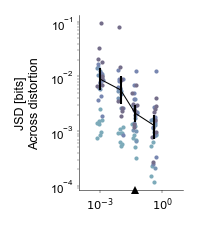

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f4.1_learns-morph/i-compare-weights.pdf')

In [203]:
def jsds_across_distortion(params):
    ex_weights = np.array([[[
        params.pose.subj_weights[scan_dataset.session_id(f"{ref_age}wk_{a}bod_m{animal_id}.{part}")]
        for part in '01']
        for a in tgt_ages]
        for animal_id in animal_ids
    ])
    return [[
        jensenshannon(ex_weights[j, i, k], ex_weights[j, 0, k], base=2)
        for j in animal_ids for k in range(2)]
        for i, a in enumerate(tgt_ages)
    ]

to_ref = [jsds_across_distortion(p) for p in model_params]

fig, ax = plt.subplots(1, 1, figsize=(1.3, 1.5), dpi=150)
viz.util.grouped_stripplot(
    {a: [np.array(refdata[i]) for refdata in to_ref] for i, a in enumerate(tgt_ages)},
    colors = sim_pal,
    x = np.log10(stiffs),
    group_order = tgt_ages,
    points_kw={'ms': 1},
    lighten_points=0.3,
    errorbar=False,
    jitter=0.15,
    offset=False
)
viz.util.grouped_stripplot(
    [np.array(refdata).ravel() for refdata in to_ref],
    colors = mpl_col.to_rgba('k'),
    x = np.log10(stiffs),
    points=False,
    errorbar_kw=dict(ms=0),
    error=lambda x: viz.util.ci(x, np.nanmean, 0.95),
    jitter=False,
)
plt.plot(np.log10(stiffs), np.mean(to_ref, axis=(1, 2)), '-', color='k', lw = 0.5)
ax.set_xlim(-4, 1)
ax.set_xticks([-3, 0])
ax.set_xticklabels(["$10^{-3}$", "$10^{0}$"])
ax.set_yscale('log')
ax.set_ylabel("JSD [bits]\nAcross distortion")
ax.set_ylim(*ax.get_ylim())
ax.plot(np.log10(stiffs[selected_model_ix]), ax.get_ylim()[0], '^', color='k', ms=4, clip_on=False, mew=0)
plotter.finalize(fig, 'i-compare-weights', despine=False)

#### Keypoint difference between session halves

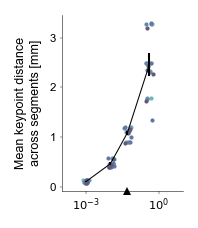

PosixPath('../../../../data_explore/plots/notebook/panels/v6/f4.1_learns-morph/i-compare-errs.pdf')

In [221]:
def crosspart_kp_errors(params):
    part0bod = {}
    part1bod = {}
    partibod = [part0bod, part1bod]

    aware_canon, _, _ = canonicalized_and_raw(scan_dataset, params.morph, None, rescale=False)

    for s in scan_dataset.sessions:
        src_s = [k for k, v in split_meta[1].items() if s in v][0]

        # Apply informed ref->part{i} body mapping for canonicalized data from `s`
        for i in range(2):
            dset = single_session_dataset(
                features.reduce_to_features(aware_canon.get_session(s), cfg['features']),
                scan_dataset.session_body_name(scan_dataset.ref_session),
                s,
                scan_dataset.session_meta,
            )
            poses = model_util.apply_bodies(
                model.morph, params.morph, dset, {s: scan_dataset.session_body_name(f"{src_s}.{i}")}
            ).get_session(s)
            partibod[i][s] = features.inflate(poses, cfg['features'])
    
    s = lambda a, j, p: f"{ref_age}wk_{a}bod_m{j}.{p}"
    return [[
        np.concatenate([
            model_util.reconst_errs(part0bod[s(a, j, part)], part1bod[s(a, j, part)], average=False)
            for part in "01"]
        ).mean()
        for j in animal_ids]
        for i, a in enumerate([ref_age] + tgt_ages)
    ]

errs = [crosspart_kp_errors(p) for p in model_params]


fig, ax = plt.subplots(1, 1, figsize=(1.3, 1.5), dpi=150)
viz.util.grouped_stripplot(
    {a: [np.array(edata[i]) for edata in errs] for i, a in enumerate([ref_age] + tgt_ages)},
    colors = sim_pal,
    x = np.log10(stiffs),
    group_order = tgt_ages,
    points_kw={'ms': 1},
    lighten_points=0.2,
    errorbar=False,
    jitter=0.15,
    offset=False
)
viz.util.grouped_stripplot(
    [np.array(edata).ravel() for edata in errs],
    colors = mpl_col.to_rgba('k'),
    x = np.log10(stiffs),
    points=False,
    errorbar_kw=dict(ms=0),
    error=lambda x: viz.util.ci(x, np.nanmean, 0.95),
    jitter=False,
)
plt.plot(np.log10(stiffs), np.mean(errs, axis=(1, 2)), '-', color='k', lw = 0.5)
ax.set_xlim(-4, 1)
ax.set_xticks([-3, 0])
ax.set_xticklabels(["$10^{-3}$", "$10^{0}$"])
ax.set_ylabel("Mean keypoint distance\nacross segments [mm]")
ax.set_ylim(*ax.get_ylim())
ax.plot(np.log10(stiffs[selected_model_ix]), ax.get_ylim()[0], '^', color='k', ms=4, clip_on=False, mew=0)
plotter.finalize(fig, 'i-compare-errs', despine=False)